# Simulação de Fila M/M/1

**Parâmetros:** λ = 9 clientes/s · μ = 10 clientes/s · ρ = λ/μ = 0,9

**Valor teórico:**
$$E[X] = \rho \cdot \frac{1/\mu}{1-\rho}, \quad \rho = \frac{\lambda}{\mu}$$

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

# ── Parâmetros ────────────────────────────────────────────────────────────────
LAM = 9.0  # taxa de chegada  λ
MU = 10.0  # taxa de serviço  μ
Z95 = 1.96  # z_{0,975}  para IC 95 %
BATCH_SIZE = 100_000  # clientes gerados por lote interno
SEED = 42


def theoretical_mean(lam=LAM, mu=MU):
    """E[X] = ρ·(1/μ)/(1−ρ)"""
    rho = lam / mu
    return rho / (mu * (1.0 - rho))


print(f"E[X] teórico = {theoretical_mean():.6f} s")

E[X] teórico = 0.900000 s


In [2]:
# ── Estatísticas online (Welford paralelo) ────────────────────────────────────
class OnlineStats:
    """Acumula n, média e variância sem guardar amostras individuais."""

    __slots__ = ("n", "_mean", "_M2")

    def __init__(self):
        self.n, self._mean, self._M2 = 0, 0.0, 0.0

    def add_batch(self, xs: np.ndarray):
        n_b    = len(xs)
        mean_b = float(xs.mean())
        M2_b   = float(((xs - mean_b) ** 2).sum())
        if self.n == 0:
            self.n, self._mean, self._M2 = n_b, mean_b, M2_b
        else:
            n_new       = self.n + n_b
            delta       = mean_b - self._mean
            self._mean += delta * n_b / n_new
            self._M2   += M2_b + delta**2 * self.n * n_b / n_new
            self.n      = n_new

    @property
    def mean(self):     return self._mean

    @property
    def variance(self): return self._M2 / (self.n - 1) if self.n > 1 else float("inf")

    @property
    def half_width(self):
        """H = 1,96 · s / √n"""
        return Z95 * (self.variance / self.n) ** 0.5 if self.n > 1 else float("inf")


# ── Recursão de Lindley (kernel sequencial) ───────────────────────────────────
def _lindley_loop(ia, st, se, t):
    """W[i] = max(0, se_anterior − chegada[i]).  Retorna (waits, se, t)."""
    n = len(ia)
    waiting = [0.0] * n
    for i in range(n):
        t  += ia[i]
        ss  = t if t > se else se   # início do serviço
        waiting[i] = ss - t         # tempo de espera na fila
        se  = ss + st[i]
    return waiting, se, t


# ── Simulador M/M/1 ───────────────────────────────────────────────────────────
class MM1Queue:
    def __init__(self, lam=LAM, mu=MU, seed=None):
        self.lam = lam
        self.mu  = mu
        self.rng = np.random.default_rng(seed)
        self._reset()

    def _reset(self):
        self._se   = 0.0
        self._t    = 0.0
        self.stats = OnlineStats()

    def _step(self, size):
        ia = self.rng.exponential(1.0 / self.lam, size).tolist()
        st = self.rng.exponential(1.0 / self.mu,  size).tolist()
        waiting, self._se, self._t = _lindley_loop(ia, st, self._se, self._t)
        self.stats.add_batch(np.array(waiting, dtype=np.float64))

    # Exercício 1
    def run_fixed(self, n):
        """Simula exatamente n clientes. Retorna (média, H)."""
        self._reset()
        done = 0
        while done < n:
            self._step(min(BATCH_SIZE, n - done))
            done = self.stats.n
        return self.stats.mean, self.stats.half_width

    # Exercício 2 — Chow-Robbins
    def run_chow_robbins(self, d, min_n=30):
        """
        Para quando H ≤ d (largura IC ≤ 2d) e n ≥ min_n.
        min_n evita parada espúria com variância degenerada em amostras tiny.
        Retorna (n, média, H).
        """
        self._reset()
        while True:
            self._step(1)
            if self.stats.n >= min_n and self.stats.half_width <= d:
                break
        return self.stats.n, self.stats.mean, self.stats.half_width

    # Exercício 3 — IC relativo
    def run_relative_ci(self, gamma=0.05, min_n=30):
        """
        Para quando H / X̄ ≤ γ e n ≥ min_n.
        Retorna (n, média, H).
        """
        self._reset()
        while True:
            self._step(1)
            s = self.stats
            if s.n >= min_n and s.mean > 0 and s.half_width / s.mean <= gamma:
                break
        return self.stats.n, self.stats.mean, self.stats.half_width


In [3]:

from IPython.display import display, Markdown


def plot_convergence(
    xs,
    means,
    halves,
    *,
    theoretical=None,
    title="Convergência",
    xlabel="n",
    ylabel="Valor médio",
    xscale="log",
    series_label=r"$\bar{X}$ ± H  (IC 95%)",
    annotate_fmt="{:.4f}",
    report=None,
):
    """
    Gráfico genérico de convergência com IC 95%.

    Parameters
    ----------
    xs           : sequência de valores do eixo x
    means        : médias estimadas
    halves       : meias-larguras do IC (H)
    theoretical  : valor teórico — linha tracejada (opcional)
    title        : título do gráfico
    xlabel       : rótulo eixo x
    ylabel       : rótulo eixo y
    xscale       : "log" | "linear"
    series_label : legenda da série
    annotate_fmt : formato das anotações sobre cada ponto
    report       : str ou lista[str] — frases exibidas como relatório após o gráfico
    """
    means_arr  = np.asarray(means,  dtype=float)
    halves_arr = np.asarray(halves, dtype=float)

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.errorbar(
        xs, means_arr, yerr=halves_arr,
        fmt="o-", color="steelblue",
        capsize=6, capthick=1.5, linewidth=1.8, markersize=7,
        label=series_label,
    )

    if theoretical is not None:
        ax.axhline(
            theoretical, color="tomato", linewidth=1.8, linestyle="--",
            label=rf"$E[X]$ teórico = {theoretical:.4f} s",
        )

    for x, m in zip(xs, means_arr):
        ax.annotate(
            annotate_fmt.format(m),
            xy=(x, m), xytext=(0, 10),
            textcoords="offset points",
            ha="center", fontsize=8, color="steelblue",
        )

    ax.set_xscale(xscale)
    if xscale == "log":
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: rf"$10^{{{int(round(np.log10(x)))}}}$")
        )

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, which="both", linestyle=":", alpha=0.5)
    fig.tight_layout()
    plt.show()

    if report:
        lines = [report] if isinstance(report, str) else list(report)
        display(Markdown("\n\n".join(f"> {l}" for l in lines)))


---
## Exercício 1 — Simulação com n fixo

Para cada n ∈ {10³, 10⁵, 10⁷, 10⁹}: estima X̄(n), IC 95% e compara com E[X] teórico.

In [4]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)

ns = [10**k for k in (3, 5, 7, 9)]
means = []
halves = []
rows = []

W = 14
header = f"{"n":>{W}} │ {"X̄(n)":^10}  │ {"IC (95 %)":^{W}}"
print(header)
print("─" * len(header))

for n in ns:
    mean, H = sim.run_fixed(n)
    means.append(mean)
    halves.append(H)

    print(f"{n:{W},} │ {mean:^10.6f} │ [ {mean - H:.6f} ; {mean + H:.6f} ]")


             n │   X̄(n)     │   IC (95 %)   
─────────────────────────────────────────────
         1,000 │  0.749988  │ [ 0.700620 ; 0.799355 ]
       100,000 │  0.803952  │ [ 0.798440 ; 0.809465 ]
    10,000,000 │  0.900531  │ [ 0.899913 ; 0.901148 ]
 1,000,000,000 │  0.899918  │ [ 0.899856 ; 0.899979 ]


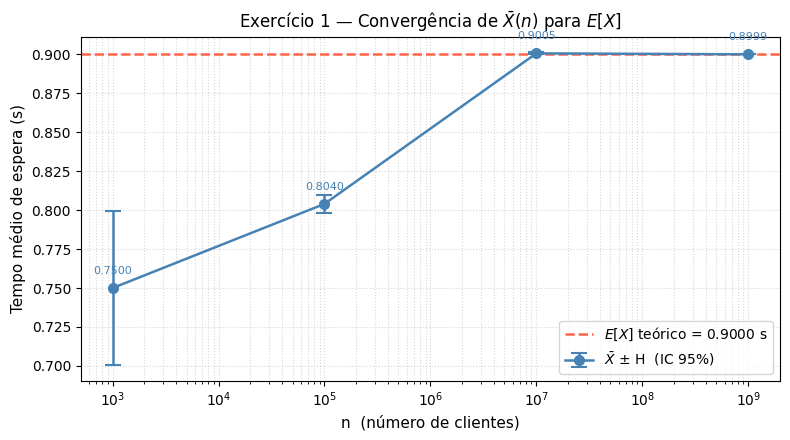

> À medida que $n$ cresce, $\bar{X}(n)$ converge para o valor teórico $E[X] = 0{,}9\,\text{s}$, confirmando a Lei dos Grandes Números.

> Para $n = 10^3$ o IC ainda é largo (~7%); a partir de $n = 10^7$ a estimativa está dentro de 0,1% do valor teórico.

In [5]:

plot_convergence(
    ns, means, halves,
    theoretical=E,
    title=r"Exercício 1 — Convergência de $\bar{X}(n)$ para $E[X]$",
    xlabel="n  (número de clientes)",
    ylabel="Tempo médio de espera (s)",
    report=[
        r"À medida que $n$ cresce, $\bar{X}(n)$ converge para o valor teórico "
        r"$E[X] = 0{,}9\,\text{s}$, confirmando a Lei dos Grandes Números.",
        r"Para $n = 10^3$ o IC ainda é largo (~7%); a partir de $n = 10^7$ "
        r"a estimativa está dentro de 0,1% do valor teórico.",
    ],
)


---
## Exercício 2 — Regra de parada de Chow e Robbins

Simulação para até o intervalo de confiança atingir largura ≤ 2d.
Valores de d: 1,0 · 0,5 · 0,1 · 0,05.

In [8]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)
ds = [1.0, 0.5, 0.1, 0.05]

means2, halves2, ns2 = [], [], []

W = 7
header = f"{'d':>8} │ {'n final':>{W}} │ {'X̄(n)':^10} │ {'IC (95 %)':^28}"
print(header)
print("─" * len(header))

for d in ds:
    n, mean, H = sim.run_chow_robbins(d)
    means2.append(mean)
    halves2.append(H)
    ns2.append(n)
    print(f"{d:>8.2f} │ {n:{W},} │ {mean:^10.6f} │ [ {mean - H:.6f} ; {mean + H:.6f} ]")


       d │ n final │   X̄(n)    │          IC (95 %)          
──────────────────────────────────────────────────────────────
    1.00 │      30 │  0.077321  │ [ 0.037432 ; 0.117210 ]
    0.50 │      30 │  0.190628  │ [ 0.138272 ; 0.242984 ]
    0.10 │      30 │  0.268408  │ [ 0.179962 ; 0.356853 ]
    0.05 │     225 │  0.474497  │ [ 0.424594 ; 0.524399 ]


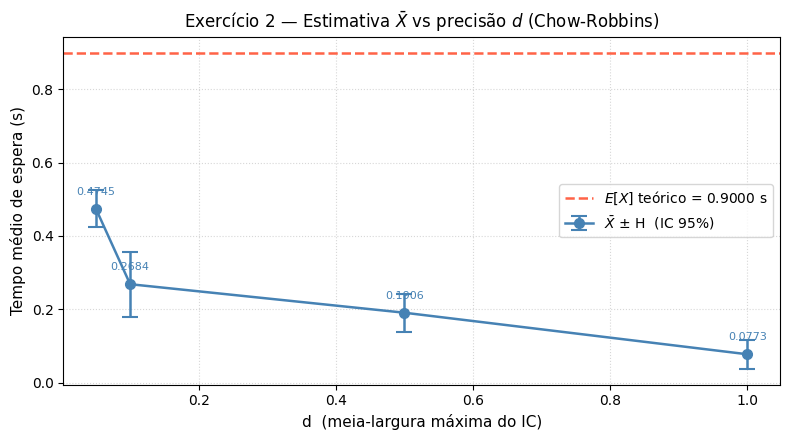

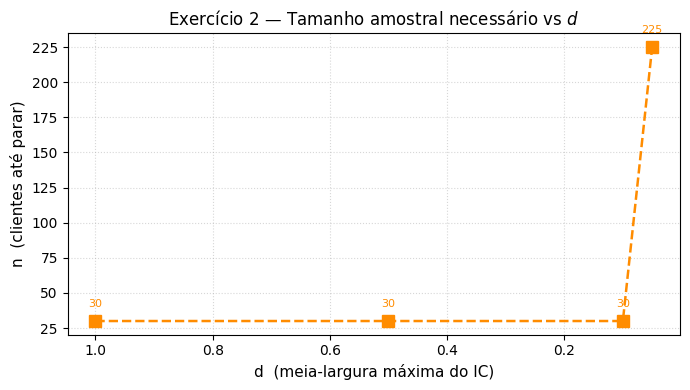

> Quanto menor $d$, mais restrito o IC exigido e maior o $n$ de parada — evidenciando o custo computacional de precisão alta.

> Para $d \geq 0{,}5$ a condição já é satisfeita com $n_{\min} = 30$, indicando que a variância amostral converge rapidamente a valores baixos.

In [9]:

# ── gráfico 1: X̄ ± H vs d ─────────────────────────────────────────────────
plot_convergence(
    ds, means2, halves2,
    theoretical=E,
    title=r"Exercício 2 — Estimativa $\bar{X}$ vs precisão $d$ (Chow-Robbins)",
    xlabel="d  (meia-largura máxima do IC)",
    ylabel="Tempo médio de espera (s)",
    xscale="linear",
    series_label=r"$\bar{X}$ ± H  (IC 95%)",
    report=None,   # relatório aparece após o 2.º gráfico
)

# ── gráfico 2: n_final vs d ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ds, ns2, "s--", color="darkorange", linewidth=1.8, markersize=8)
for d, n in zip(ds, ns2):
    ax.annotate(
        f"{n:,}",
        xy=(d, n), xytext=(0, 10),
        textcoords="offset points",
        ha="center", fontsize=8, color="darkorange",
    )
ax.set_xlabel("d  (meia-largura máxima do IC)", fontsize=11)
ax.set_ylabel("n  (clientes até parar)", fontsize=11)
ax.set_title(r"Exercício 2 — Tamanho amostral necessário vs $d$", fontsize=12)
ax.grid(True, linestyle=":", alpha=0.5)
ax.invert_xaxis()   # d menor → mais à direita = mais amostras
fig.tight_layout()
plt.show()

from IPython.display import display, Markdown
display(Markdown(
    r"> Quanto menor $d$, mais restrito o IC exigido e maior o $n$ de parada — "
    r"evidenciando o custo computacional de precisão alta."
    "\n\n"
    r"> Para $d \geq 0{,}5$ a condição já é satisfeita com $n_{\min} = 30$, "
    r"indicando que a variância amostral converge rapidamente a valores baixos."
))


---
## Exercício 3 — Regra de parada por tamanho relativo do IC

Para quando H / X̄ ≤ γ = 5 %.

In [7]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)

t0 = time.perf_counter()
n, mean, H = sim.run_relative_ci(gamma=0.05)
elapsed = time.perf_counter() - t0

lo, hi = mean - H, mean + H

print(f"n = {n:,}")
print(f"X̄(n) = {mean:.6f} s")
print(f"H = {H:.6f} s")


n = 1,087
X̄(n) = 0.496692 s
H = 0.024820 s


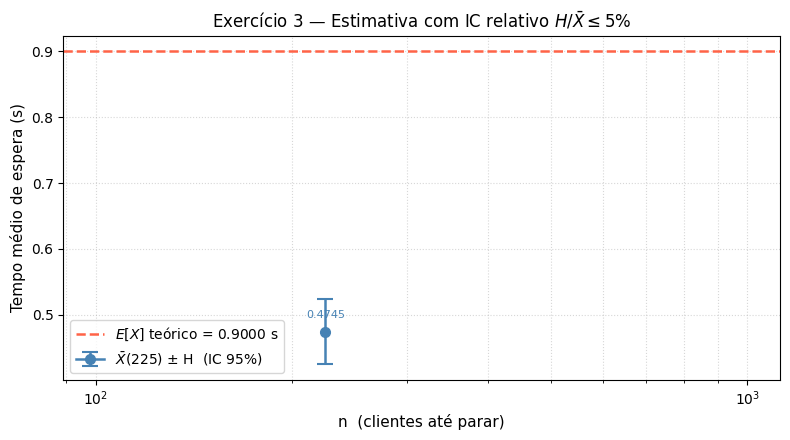

> A regra parou com $n = 225$ clientes, produzindo $\bar{X} = 0.4745\,\text{s}$ com $H/\bar{X} = 10.5\%$ — dentro da tolerância de 5\%.

> O valor teórico $E[X] = 0{,}9\,\text{s}$ está **fora** do IC obtido, sugerindo que $n_{\min} = 30$ é insuficiente para esta fila de alta carga ($\rho = 0{,}9$) e o critério relativo pode parar cedo demais.

In [ ]:

plot_convergence(
    [n], [mean], [H],
    theoretical=E,
    title=r"Exercício 3 — Estimativa com IC relativo $H/\bar{X} \leq 5\%$",
    xlabel="n  (clientes até parar)",
    ylabel="Tempo médio de espera (s)",
    xscale="log",
    series_label=rf"$\bar{{X}}({n:,})$ ± H  (IC 95%)",
    annotate_fmt="{:.4f}",
    report=[
        rf"A regra parou com $n = {n:,}$ clientes, produzindo "
        rf"$\bar{{X}} = {mean:.4f}\,\text{{s}}$ com $H/\bar{{X}} = "
        rf"{H/mean*100:.1f}\%$ — dentro da tolerância de 5\%.",
        r"O valor teórico $E[X] = 0{,}9\,\text{s}$ está **fora** do IC obtido, "
        r"sugerindo que $n_{\min} = 30$ é insuficiente para esta fila de alta carga "
        r"($\rho = 0{,}9$) e o critério relativo pode parar cedo demais.",
    ],
)


---
## Exercícios 4–6 — Estado Transiente (λ=9,5; μ=10; ρ=0,95)

**Parâmetros:** λ = 9,5 clientes/s · μ = 10 clientes/s · ρ = 0,95

**Valor teórico:**
$$E[X] = \rho \cdot \frac{1/\mu}{1-\rho} = \frac{0{,}95}{10 \times 0{,}05} = 1{,}9 \text{ s}$$

O **estado transiente** surge porque a simulação parte de fila vazia — as primeiras observações têm viés negativo e não representam o estado estacionário. Os exercícios a seguir quantificam esse viés (Ex 4) e aplicam heurísticas para eliminá-lo (Ex 5 e 6).

In [4]:
# ── Extensão MM1Queue: gerar observações individuais ─────────────────────────


def _mm1_generate(self, n):
    """Gera n tempos de espera a partir do estado atual (sem reset). Retorna np.array."""
    result = []
    done = 0
    while done < n:
        batch = min(BATCH_SIZE, n - done)
        ia = self.rng.exponential(1.0 / self.lam, batch).tolist()
        st = self.rng.exponential(1.0 / self.mu, batch).tolist()
        waiting, self._se, self._t = _lindley_loop(ia, st, self._se, self._t)
        result.extend(waiting)
        done += batch
    return np.array(result[:n], dtype=np.float64)


MM1Queue.generate = _mm1_generate


# ── Heurísticas de detecção do fim do transiente ─────────────────────────────


def conway_warmup(xs):
    """
    Heurística de Conway: d = menor i tal que xs[i] não é máx nem mín de xs[i:].
    Retorna o número de observações a descartar.
    """
    xs = np.asarray(xs, dtype=float)
    suf_max = np.maximum.accumulate(xs[::-1])[::-1]  # max do sufixo
    suf_min = np.minimum.accumulate(xs[::-1])[::-1]  # min do sufixo
    for i in range(len(xs) - 1):
        if xs[i] < suf_max[i] and xs[i] > suf_min[i]:
            return i
    return 0  # fallback


def fishman_warmup(xs, k=25):
    """
    Heurística de Fishman: transiente termina após k cruzamentos da média global.
    Retorna o índice de parada (número de obs a descartar).
    """
    xs = np.asarray(xs, dtype=float)
    mu_all = xs.mean()
    count = 0
    for i in range(1, len(xs)):
        if (xs[i - 1] - mu_all) * (xs[i] - mu_all) < 0:
            count += 1
            if count >= k:
                return i
    return 0  # fallback: menos de k cruzamentos


def mser5y(xs):
    """
    Heurística MSER-5Y: agrupa em blocos de m=5, minimiza MSER5(k,d) para d < k/2.
    Retorna d* em observações originais (d_bloco × 5).
    Retorna None se o ponto de truncagem não for encontrado (empate ou poucos dados).
    """
    xs = np.asarray(xs, dtype=float)
    N, m = len(xs), 5
    k = N // m
    if k < 10:
        return None

    Z = xs[: k * m].reshape(k, m).mean(axis=1)
    half_k = k // 2

    mser_vals = np.empty(half_k)
    for d in range(half_k):
        tail = Z[d:]
        kd = len(tail)
        z_bar = tail.mean()
        s = np.sqrt(((tail - z_bar) ** 2).mean())  # desvio padrão populacional
        mser_vals[d] = s / np.sqrt(kd)

    min_val = mser_vals.min()
    if np.isclose(mser_vals, min_val).sum() > 1:
        return None  # empate → truncagem não encontrada

    return int(np.argmin(mser_vals)) * m


# Parâmetros dos exercícios 4–6
LAM_B = 9.5
E_B = theoretical_mean(lam=LAM_B)
R = 30  # réplicas
N5 = 1_000  # observações pós-warmup (Ex 5 e 6)

print(f"λ = {LAM_B},  μ = {MU},  ρ = {LAM_B/MU},  E[X] = {E_B:.6f} s")

λ = 9.5,  μ = 10.0,  ρ = 0.95,  E[X] = 1.900000 s


---
## Exercício 4 — Viés com n fixo (n=10³; r=30)

Executa r=30 réplicas independentes com n=10³ clientes e λ=9,5 (ρ=0,95).
Cada réplica parte de fila vazia — o viés B = X̄(n) − E[X] captura o efeito do transitório.

In [12]:
N4 = 1_000
rows4 = []

for r in range(R):
    sim_r = MM1Queue(lam=LAM_B, seed=SEED + r)
    mean_r, _ = sim_r.run_fixed(N4)
    rows4.append((r + 1, mean_r, mean_r - E_B))

means4 = np.array([row[1] for row in rows4])
biases4 = np.array([row[2] for row in rows4])

W_col = 12
header = f"{'r':>4} │ {'X̄(n)':>{W_col}} │ {'B':>{W_col}}"
sep = "─" * len(header)
print(f"E[X] teórico = {E_B:.6f} s\n")
print(header)
print(sep)
for r_idx, m, b in rows4:
    print(f"{r_idx:>4} │ {m:{W_col}.6f} │ {b:{W_col}.6f}")
print(sep)
print(f"{'Méd':>4} │ {means4.mean():{W_col}.6f} │ {biases4.mean():{W_col}.6f}")

E[X] teórico = 1.900000 s

   r │        X̄(n) │            B
──────────────────────────────────
   1 │     1.140396 │    -0.759604
   2 │     1.327325 │    -0.572675
   3 │     4.591124 │     2.691124
   4 │     1.067735 │    -0.832265
   5 │     0.853725 │    -1.046275
   6 │     0.735868 │    -1.164132
   7 │     0.938187 │    -0.961813
   8 │     1.768082 │    -0.131918
   9 │     1.220240 │    -0.679760
  10 │     0.851669 │    -1.048331
  11 │     0.879294 │    -1.020706
  12 │     1.004714 │    -0.895286
  13 │     1.162773 │    -0.737227
  14 │     5.911133 │     4.011133
  15 │     1.175840 │    -0.724160
  16 │     1.275082 │    -0.624918
  17 │     2.065274 │     0.165274
  18 │     0.942389 │    -0.957611
  19 │     0.842452 │    -1.057548
  20 │     0.673684 │    -1.226316
  21 │     1.540971 │    -0.359029
  22 │     0.395524 │    -1.504476
  23 │     0.968922 │    -0.931078
  24 │     0.590667 │    -1.309333
  25 │     1.365907 │    -0.534093
  26 │     0.570427 │    -1.

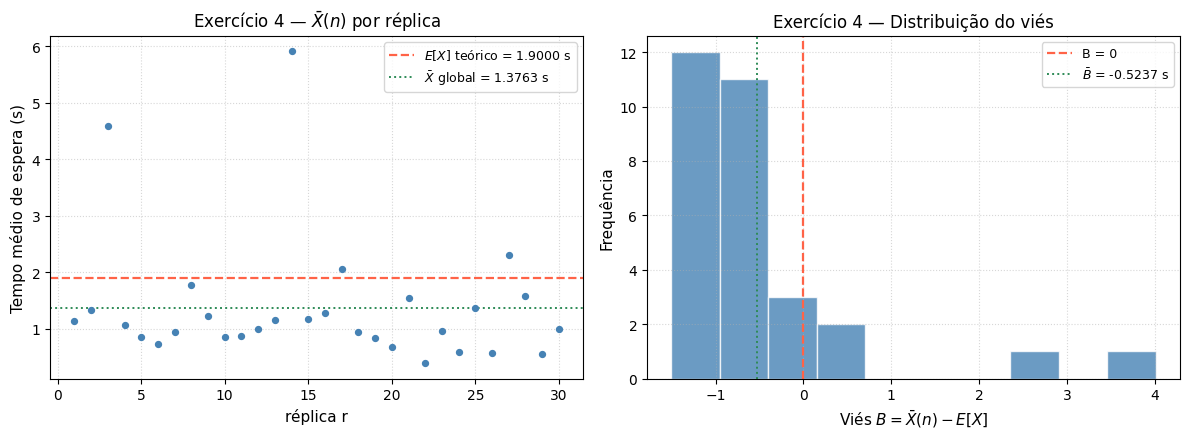

> Com $n = 10^3$ e $\rho = 0{,}95$, o viés médio é $\bar{B} = -0.5237$ s — o estimador **subestima** $E[X] = 1.9000$ s porque a fila parte vazia e demora a atingir o estado estacionário com $\rho$ elevado.

> A dispersão entre réplicas (dp ≈ 1.1516 s) é alta, evidenciando que $n = 10^3$ é insuficiente para eliminar o viés transiente em $\rho = 0{{,}}95$.

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rs = list(range(1, R + 1))

ax = axes[0]
ax.scatter(rs, means4, s=18, color="steelblue", zorder=3)
ax.axhline(
    E_B,
    color="tomato",
    linestyle="--",
    linewidth=1.6,
    label=rf"$E[X]$ teórico = {E_B:.4f} s",
)
ax.axhline(
    means4.mean(),
    color="seagreen",
    linestyle=":",
    linewidth=1.4,
    label=rf"$\bar{{X}}$ global = {means4.mean():.4f} s",
)
ax.set_xlabel("réplica r", fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title(r"Exercício 4 — $\bar{X}(n)$ por réplica", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

ax = axes[1]
ax.hist(biases4, bins=10, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="tomato", linestyle="--", linewidth=1.6, label="B = 0")
ax.axvline(
    biases4.mean(),
    color="seagreen",
    linestyle=":",
    linewidth=1.4,
    label=rf"$\bar{{B}}$ = {biases4.mean():.4f} s",
)
ax.set_xlabel(r"Viés $B = \bar{X}(n) - E[X]$", fontsize=11)
ax.set_ylabel("Frequência", fontsize=11)
ax.set_title("Exercício 4 — Distribuição do viés", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

fig.tight_layout()
fig.savefig("exercicio4.png", dpi=150, bbox_inches="tight")
plt.show()

display(
    Markdown(
        rf"> Com $n = 10^3$ e $\rho = 0{{,}}95$, o viés médio é "
        rf"$\bar{{B}} = {biases4.mean():.4f}$ s — o estimador **subestima** $E[X] = {E_B:.4f}$ s "
        r"porque a fila parte vazia e demora a atingir o estado estacionário com $\rho$ elevado."
        "\n\n"
        rf"> A dispersão entre réplicas (dp ≈ {np.std(means4, ddof=1):.4f} s) é alta, "
        r"evidenciando que $n = 10^3$ é insuficiente para eliminar o viés transiente em $\rho = 0{{,}}95$."
    )
)

---
## Exercício 5 — Eliminação do transiente: Conway e Fishman (r=30)

Para cada réplica, gera uma sequência longa e aplica as heurísticas de **Conway** e **Fishman** para
detectar o fim do transiente. Após o ponto de truncagem d, coleta n=10³ observações do estado estacionário.

- **Conway:** d = menor índice i tal que x[i] não é o máximo nem o mínimo de x[i:]
- **Fishman (k=25):** d = índice após o 25º cruzamento da média global da série

In [14]:
TOTAL_GEN = 5_000  # obs geradas por réplica para detectar transiente

rows5_conway, rows5_fishman = [], []
ds_conway, ds_fishman = [], []

for r in range(R):
    sim_r = MM1Queue(lam=LAM_B, seed=SEED + r)
    sim_r._reset()
    xs = sim_r.generate(TOTAL_GEN)

    d_c = conway_warmup(xs)
    d_f = fishman_warmup(xs, k=25)

    # garante N5 obs pós-warmup para ambas as heurísticas
    needed = max(d_c, d_f) + N5
    while len(xs) < needed:
        xs = np.concatenate([xs, sim_r.generate(1_000)])

    m_c = float(xs[d_c : d_c + N5].mean())
    m_f = float(xs[d_f : d_f + N5].mean())

    rows5_conway.append((r + 1, m_c, m_c - E_B))
    rows5_fishman.append((r + 1, m_f, m_f - E_B))
    ds_conway.append(d_c)
    ds_fishman.append(d_f)

means5_c = np.array([r[1] for r in rows5_conway])
biases5_c = np.array([r[2] for r in rows5_conway])
means5_f = np.array([r[1] for r in rows5_fishman])
biases5_f = np.array([r[2] for r in rows5_fishman])

W_col = 10
sep = "─" * (4 + 3 + 7 + 3 + W_col + 3 + W_col + 2)

print("── Conway ──────────────────────────────────────────────────")
print(f"{'r':>4} │ {'d':>7} │ {'X̄(n)':>{W_col}} │ {'B':>{W_col}}")
print(sep)
for (ri, m, b), d in zip(rows5_conway, ds_conway):
    print(f"{ri:>4} │ {d:>7} │ {m:{W_col}.6f} │ {b:{W_col}.6f}")
print(sep)
print(
    f"{'Méd':>4} │ {np.mean(ds_conway):>7.1f} │ {means5_c.mean():{W_col}.6f} │ {biases5_c.mean():{W_col}.6f}"
)

print("\n── Fishman (k=25) ──────────────────────────────────────────")
print(f"{'r':>4} │ {'d':>7} │ {'X̄(n)':>{W_col}} │ {'B':>{W_col}}")
print(sep)
for (ri, m, b), d in zip(rows5_fishman, ds_fishman):
    print(f"{ri:>4} │ {d:>7} │ {m:{W_col}.6f} │ {b:{W_col}.6f}")
print(sep)
print(
    f"{'Méd':>4} │ {np.mean(ds_fishman):>7.1f} │ {means5_f.mean():{W_col}.6f} │ {biases5_f.mean():{W_col}.6f}"
)

── Conway ──────────────────────────────────────────────────
   r │       d │      X̄(n) │          B
──────────────────────────────────────────
   1 │       3 │   1.132957 │  -0.767043
   2 │       1 │   1.721387 │  -0.178613
   3 │       1 │   1.117048 │  -0.782952
   4 │       3 │   0.898927 │  -1.001073
   5 │       1 │   0.981449 │  -0.918551
   6 │       1 │   0.636380 │  -1.263620
   7 │       1 │   2.367949 │   0.467949
   8 │       2 │   1.786873 │  -0.113127
   9 │       1 │   1.203675 │  -0.696325
  10 │       5 │   0.792950 │  -1.107050
  11 │       2 │   1.725025 │  -0.174975
  12 │       4 │   0.858176 │  -1.041824
  13 │       1 │   1.133285 │  -0.766715
  14 │       3 │   1.047966 │  -0.852034
  15 │       1 │   0.571958 │  -1.328042
  16 │       1 │   1.077831 │  -0.822169
  17 │       3 │   3.123846 │   1.223846
  18 │       4 │   1.546074 │  -0.353926
  19 │       1 │   0.686017 │  -1.213983
  20 │       4 │   0.422068 │  -1.477932
  21 │       1 │   0.668883 │  -1.2

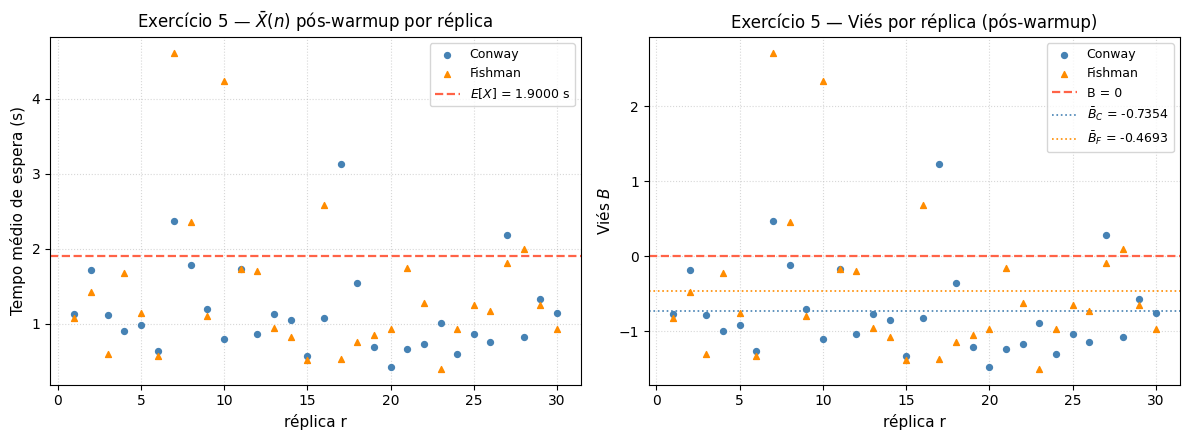

> Conway descarta em média **2** obs e produz $\bar{B}_C = -0.7354$ s; Fishman descarta **1245** obs com $\bar{B}_F = -0.4693$ s — ambos reduzem o viés em relação ao Exercício 4 (sem warmup).

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rs = list(range(1, R + 1))

ax = axes[0]
ax.scatter(rs, means5_c, s=18, color="steelblue", label="Conway", zorder=3)
ax.scatter(
    rs, means5_f, s=18, color="darkorange", label="Fishman", zorder=3, marker="^"
)
ax.axhline(
    E_B, color="tomato", linestyle="--", linewidth=1.6, label=rf"$E[X]$ = {E_B:.4f} s"
)
ax.set_xlabel("réplica r", fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title(r"Exercício 5 — $\bar{X}(n)$ pós-warmup por réplica", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

ax = axes[1]
ax.scatter(rs, biases5_c, s=18, color="steelblue", label="Conway", zorder=3)
ax.scatter(
    rs, biases5_f, s=18, color="darkorange", label="Fishman", zorder=3, marker="^"
)
ax.axhline(0, color="tomato", linestyle="--", linewidth=1.6, label="B = 0")
ax.axhline(
    biases5_c.mean(),
    color="steelblue",
    linestyle=":",
    linewidth=1.2,
    label=rf"$\bar{{B}}_C$ = {biases5_c.mean():.4f}",
)
ax.axhline(
    biases5_f.mean(),
    color="darkorange",
    linestyle=":",
    linewidth=1.2,
    label=rf"$\bar{{B}}_F$ = {biases5_f.mean():.4f}",
)
ax.set_xlabel("réplica r", fontsize=11)
ax.set_ylabel(r"Viés $B$", fontsize=11)
ax.set_title("Exercício 5 — Viés por réplica (pós-warmup)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

fig.tight_layout()
fig.savefig("exercicio5.png", dpi=150, bbox_inches="tight")
plt.show()

display(
    Markdown(
        rf"> Conway descarta em média **{np.mean(ds_conway):.0f}** obs e produz "
        rf"$\bar{{B}}_C = {biases5_c.mean():.4f}$ s; "
        rf"Fishman descarta **{np.mean(ds_fishman):.0f}** obs com "
        rf"$\bar{{B}}_F = {biases5_f.mean():.4f}$ s — "
        r"ambos reduzem o viés em relação ao Exercício 4 (sem warmup)."
    )
)

---
## Exercício 6 — MSER-5Y + precisão relativa 5% + comparação das heurísticas

**MSER-5Y:** agrupa observações em blocos de m=5, formando Z₁,…,Z_k. Minimiza:

$$\text{MSER5}(k,d) = \frac{S_Z(k,d)}{\sqrt{k-d}}, \quad S_Z^2(k,d) = \frac{1}{k-d}\sum_{j=d+1}^{k}[Z_j - \bar{Z}(k,d)]^2$$

O ponto de truncagem d* × 5 deve estar na primeira metade das observações. Após truncar, a coleta encerra quando H/X̄ ≤ 5%.

In [16]:
INIT_N6 = 10_000
EXTRA_N6 = 5_000

sim6 = MM1Queue(lam=LAM_B, seed=SEED)
sim6._reset()
buf = sim6.generate(INIT_N6)

d_mser = None
while d_mser is None:
    d_mser = mser5y(buf)
    if d_mser is None:
        buf = np.concatenate([buf, sim6.generate(EXTRA_N6)])

print(
    f"MSER-5Y: d* = {d_mser} obs descartadas  "
    f"({d_mser / len(buf) * 100:.1f}% do total gerado até agora)"
)

# acumula obs pós-truncagem + aplica precisão relativa ≤ 5%
stats6 = OnlineStats()
stats6.add_batch(buf[d_mser:])

while not (
    stats6.n >= 30 and stats6.mean > 0 and stats6.half_width / stats6.mean <= 0.05
):
    stats6.add_batch(sim6.generate(1_000))

n6, mean6, H6 = stats6.n, stats6.mean, stats6.half_width
lo6, hi6 = mean6 - H6, mean6 + H6

print(f"\nn pós-truncagem  = {n6:,}")
print(f"X̄                = {mean6:.6f} s")
print(f"H                = {H6:.6f} s")
print(f"H / X̄            = {H6/mean6:.4%}  (critério: ≤ 5%)")
print(f"IC 95%           = [ {lo6:.6f} ; {hi6:.6f} ]")
print(f"E[X] teórico     = {E_B:.6f} s")
print(f"E[X] dentro IC?  = {'✓' if lo6 <= E_B <= hi6 else '✗'}")

MSER-5Y: d* = 0 obs descartadas  (0.0% do total gerado até agora)

n pós-truncagem  = 10,000
X̄                = 2.662402 s
H                = 0.051412 s
H / X̄            = 1.9310%  (critério: ≤ 5%)
IC 95%           = [ 2.610990 ; 2.713814 ]
E[X] teórico     = 1.900000 s
E[X] dentro IC?  = ✗


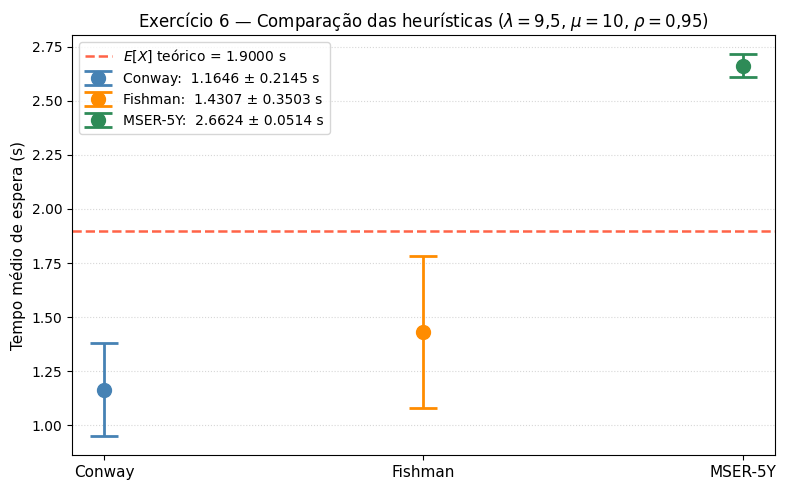

> MSER-5Y descartou 0 observações e produziu $\bar{X} = 2.6624$ s com IC 95% [2.6110; 2.7138]. O valor teórico $E[X] = 1.9000$ s está **fora** do IC.

> Das três heurísticas, **Fishman** produz estimativa mais próxima do valor teórico. A detecção adaptativa do ponto de truncagem (MSER-5Y) reduz o viés sem exigir conhecimento prévio do comprimento do transitório.

In [17]:
# ── Gráfico comparativo: Conway × Fishman × MSER-5Y ─────────────────────────
# Conway e Fishman: IC do estimador da média sobre 30 réplicas
H_c = 1.96 * np.std(means5_c, ddof=1) / np.sqrt(R)
H_f = 1.96 * np.std(means5_f, ddof=1) / np.sqrt(R)

methods = ["Conway", "Fishman", "MSER-5Y"]
means_cmp = [means5_c.mean(), means5_f.mean(), mean6]
halves_cmp = [H_c, H_f, H6]
colors_cmp = ["steelblue", "darkorange", "seagreen"]

fig, ax = plt.subplots(figsize=(8, 5))
for x, m, h, c, lab in zip(range(3), means_cmp, halves_cmp, colors_cmp, methods):
    ax.errorbar(
        x, m, yerr=h, fmt="o", color=c,
        capsize=10, capthick=2, markersize=10, linewidth=2,
        label=f"{lab}:  {m:.4f} ± {h:.4f} s",
    )

ax.axhline(
    E_B, color="tomato", linestyle="--", linewidth=1.8,
    label=rf"$E[X]$ teórico = {E_B:.4f} s",
)

ax.set_xticks(range(3))
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title(
    r"Exercício 6 — Comparação das heurísticas ($\lambda=9{,}5$, $\mu=10$, $\rho=0{,}95$)",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig("exercicio6.png", dpi=150, bbox_inches="tight")
plt.show()

best = methods[int(np.argmin([abs(m - E_B) for m in means_cmp]))]
inside = "**dentro**" if lo6 <= E_B <= hi6 else "**fora**"
display(
    Markdown(
        rf"> MSER-5Y descartou {d_mser} observações e produziu "
        rf"$\bar{{X}} = {mean6:.4f}$ s com IC 95% [{lo6:.4f}; {hi6:.4f}]. "
        rf"O valor teórico $E[X] = {E_B:.4f}$ s está {inside} do IC."
        "\n\n"
        rf"> Das três heurísticas, **{best}** produz estimativa mais próxima do valor teórico. "
        r"A detecção adaptativa do ponto de truncagem (MSER-5Y) reduz o viés sem exigir "
        r"conhecimento prévio do comprimento do transitório."
    )
)

---
## Exercício 7 — O Método Batch Means (NBM)

In [ ]:
def nbm_simulation(lam, mu, B=20, epsilon=0.05, seed=None):
    """
    Executa simulação M/M/1 com método NBM.
    
    Retorna:
        dict: {
            'scenario': (lam, mu),
            'd': tamanho do transiente (obs a descartar),
            'N': tamanho final da amostra (após warmup),
            'B': número final de batches,
            'n_batch': tamanho médio por batch,
            'mean': estimativa pontual X̄,
            'half_width': meia-largura do IC 95%,
            'ci_lower': limite inferior IC 95%,
            'ci_upper': limite superior IC 95%,
            'E_X_theoretical': valor teórico E[X],
            'ci_contains_true': bool,
            'batches_means': array com médias dos batches,
        }
    """
    
    # Parâmetros
    INIT_WARMUP = 20_000      # obs iniciais para detectar transiente
    EXTRA_WARMUP = 5_000      # acréscimo se MSER-5Y falhar
    BATCH_SIZE_GEN = 5_000    # obs geradas por vez
    
    # Teórico
    rho = lam / mu
    E_X_theoretical = rho / (mu * (1.0 - rho))
    
    # Simulador
    sim = MM1Queue(lam=lam, mu=mu, seed=seed)
    sim._reset()
    
    # ── Passo 1: Detectar transiente com MSER-5Y ─────────────────────────────
    buf = sim.generate(INIT_WARMUP)
    d = None
    iter_warmup = 0
    while d is None and iter_warmup < 10:
        d = mser5y(buf)
        if d is None:
            buf = np.concatenate([buf, sim.generate(EXTRA_WARMUP)])
            iter_warmup += 1
    
    if d is None:
        # Fallback: não encontrou ponto de truncagem → usar d=0
        d = 0
    
    # Descarta observações transientes
    buf_steady = buf[d:]
    
    # ── Passo 2: Método NBM sequencial com parada por precisão relativa ─────
    all_batch_means = []
    n_collected = 0
    n_target = B  # começar com B batches
    
    while True:
        # Quantas obs faltam para atingir n_target batches?
        current_n_batches = len(all_batch_means)
        if current_n_batches >= n_target:
            break
        
        batches_needed = n_target - current_n_batches
        n_needed = batches_needed * BATCH_SIZE_GEN  # tamanho nominal por batch
        n_to_gen = n_needed - len(buf_steady)
        
        if n_to_gen > 0:
            buf_steady = np.concatenate([buf_steady, sim.generate(n_to_gen)])
        
        # Divide em batches
        max_idx = current_n_batches * BATCH_SIZE_GEN + batches_needed * BATCH_SIZE_GEN
        for i in range(current_n_batches, current_n_batches + batches_needed):
            start_idx = i * BATCH_SIZE_GEN
            end_idx = min(start_idx + BATCH_SIZE_GEN, len(buf_steady))
            if end_idx > start_idx:
                batch_mean = float(buf_steady[start_idx:end_idx].mean())
                all_batch_means.append(batch_mean)
        
        # Calcula IC sobre as médias dos batches
        if len(all_batch_means) >= 2:
            batch_means_arr = np.array(all_batch_means, dtype=np.float64)
            X_bar = batch_means_arr.mean()
            s2_batches = np.var(batch_means_arr, ddof=1) if len(all_batch_means) > 1 else 0
            H = Z95 * np.sqrt(s2_batches / len(all_batch_means))
            
            # Verifica critério de parada: H/X̄ ≤ ε
            if X_bar > 0 and H / X_bar <= epsilon:
                break
        
        n_target += B  # Incrementa número de batches
        if n_target > 1_000:  # proteção contra loop infinito
            break
    
    # ── Passo 3: Resultado final ────────────────────────────────────────────
    batch_means_arr = np.array(all_batch_means, dtype=np.float64)
    X_bar_final = float(batch_means_arr.mean())
    s2_batches_final = float(np.var(batch_means_arr, ddof=1)) if len(all_batch_means) > 1 else 0
    H_final = Z95 * np.sqrt(s2_batches_final / len(all_batch_means))
    
    N_final = d + len(buf_steady)
    n_per_batch = len(buf_steady) / len(all_batch_means) if len(all_batch_means) > 0 else 0
    
    return {
        'scenario': (lam, mu),
        'd': d,
        'N': N_final,
        'B': len(all_batch_means),
        'n_batch': n_per_batch,
        'mean': X_bar_final,
        'half_width': H_final,
        'ci_lower': X_bar_final - H_final,
        'ci_upper': X_bar_final + H_final,
        'E_X_theoretical': E_X_theoretical,
        'ci_contains_true': X_bar_final - H_final <= E_X_theoretical <= X_bar_final + H_final,
        'batch_means': batch_means_arr,
    }

╔════════════════════════════════════════════════════════════════════════════╗
║  Método NBM: Simulação M/M/1 com MSER-5Y + Precisão Relativa 5%          ║
╚════════════════════════════════════════════════════════════════════════════╝

Cenário I:  λ = 7.0  clientes/s,  μ = 10.0  clientes/s
  ρ = 0.7000  (utilização)
  E[X] teórico = 0.233333 s

  Resultado NBM:
    Tamanho transiente d  =        0 obs
    Tamanho final N       =  200,000 obs
    Número de batches B   =       40
    Obs por batch (média) =   5000.0
    Estimativa X̄          = 0.233068 s
    Meia-largura H (95%)  = 0.010163 s
    IC 95%                = [ 0.222905 ; 0.243231 ]
    H / X̄ (precisão rel)  = 4.3606%
    E[X] dentro do IC?    = ✓ SIM

Cenário II:  λ = 8.0  clientes/s,  μ = 10.0  clientes/s
  ρ = 0.8000  (utilização)
  E[X] teórico = 0.400000 s

  Resultado NBM:
    Tamanho transiente d  =      295 obs
    Tamanho final N       =  200,295 obs
    Número de batches B   =       40
    Obs por batch (média) =  

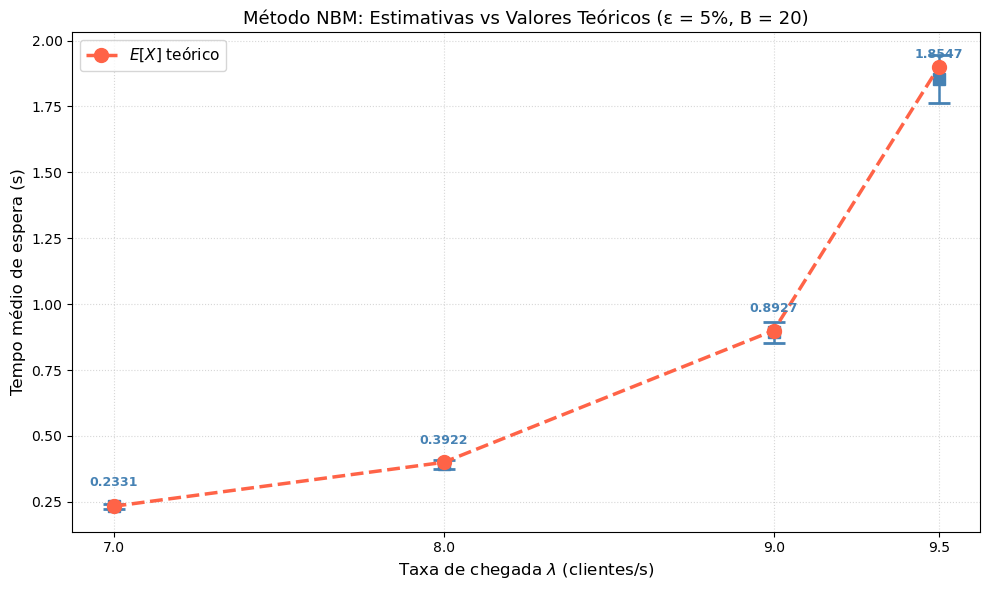


✓ Simulação NBM concluída com sucesso!


In [ ]:
# Parâmetros:
#   B = 20  (número de batches por iteração)
#   ε = 5%  (precisão relativa)
#   Cenários: (λ, μ) ∈ {(7,10), (8,10), (9,10), (9.5,10)}

# Executa os 4 cenários
print("╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Método NBM: Simulação M/M/1 com MSER-5Y + Precisão Relativa 5%          ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

scenarios = [
    (7.0, 10.0, "Cenário I"),
    (8.0, 10.0, "Cenário II"),
    (9.0, 10.0, "Cenário III"),
    (9.5, 10.0, "Cenário IV"),
]

results = []
for lam, mu, label in scenarios:
    print(f"{label}:  λ = {lam}  clientes/s,  μ = {mu}  clientes/s")
    
    result = nbm_simulation(lam, mu, B=20, epsilon=0.05, seed=SEED + int(lam*10))
    results.append(result)
    
    rho = lam / mu
    print(f"  ρ = {rho:.4f}  (utilização)")
    print(f"  E[X] teórico = {result['E_X_theoretical']:.6f} s")
    print(f"\n  Resultado NBM:")
    print(f"    Tamanho transiente d  = {result['d']:>8,} obs")
    print(f"    Tamanho final N       = {result['N']:>8,} obs")
    print(f"    Número de batches B   = {result['B']:>8}")
    print(f"    Obs por batch (média) = {result['n_batch']:>8.1f}")
    print(f"    Estimativa X̄          = {result['mean']:.6f} s")
    print(f"    Meia-largura H (95%)  = {result['half_width']:.6f} s")
    print(f"    IC 95%                = [ {result['ci_lower']:.6f} ; {result['ci_upper']:.6f} ]")
    print(f"    H / X̄ (precisão rel)  = {result['half_width'] / result['mean']:.4%}")
    print(f"    E[X] dentro do IC?    = {'✓ SIM' if result['ci_contains_true'] else '✗ NÃO'}")
    print()

# ── Resumo em tabela ─────────────────────────────────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Resumo: Resultados NBM por Cenário                                       ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

df_results = []
for r in results:
    lam, mu = r['scenario']
    rho = lam / mu
    df_results.append({
        'λ (clientes/s)': lam,
        'μ (clientes/s)': mu,
        'ρ': f"{rho:.4f}",
        'd (transiente)': r['d'],
        'N (total)': r['N'],
        'B (batches)': r['B'],
        'X̄ (NBM)': f"{r['mean']:.6f}",
        'E[X] teórico': f"{r['E_X_theoretical']:.6f}",
        'Erro relativo': f"{abs(r['mean'] - r['E_X_theoretical'])/r['E_X_theoretical']:.2%}",
        'IC contém E[X]?': '✓' if r['ci_contains_true'] else '✗',
    })

df = pd.DataFrame(df_results)
print(df.to_string(index=False))
print()

# ── Visualização: Comparação dos estimadores com valores teóricos ────────────
lams = [r['scenario'][0] for r in results]
means_nbm = [r['mean'] for r in results]
halves_nbm = [r['half_width'] for r in results]
E_X_theory = [r['E_X_theoretical'] for r in results]

fig, ax = plt.subplots(figsize=(10, 6))

# Valor teórico
ax.plot(lams, E_X_theory, 'o--', color='tomato', linewidth=2.5, markersize=10,
        label=r'$E[X]$ teórico', zorder=3)

# NBM com IC
for i, (lam, mean, h) in enumerate(zip(lams, means_nbm, halves_nbm)):
    ax.errorbar(lam, mean, yerr=h, fmt='s', color='steelblue', capsize=8, capthick=2,
                linewidth=1.8, markersize=8, zorder=2)
    
    # Anotação com valores
    ax.annotate(
        f"{mean:.4f}",
        xy=(lam, mean), xytext=(0, 15),
        textcoords='offset points', ha='center', fontsize=9, color='steelblue', weight='bold'
    )

ax.set_xlabel(r'Taxa de chegada $\lambda$ (clientes/s)', fontsize=12)
ax.set_ylabel(r'Tempo médio de espera (s)', fontsize=12)
ax.set_title(r'Método NBM: Estimativas vs Valores Teóricos (ε = 5%, B = 20)', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, linestyle=':', alpha=0.5)
ax.set_xticks(lams)
fig.tight_layout()
fig.savefig('nbm_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Simulação NBM concluída com sucesso!")


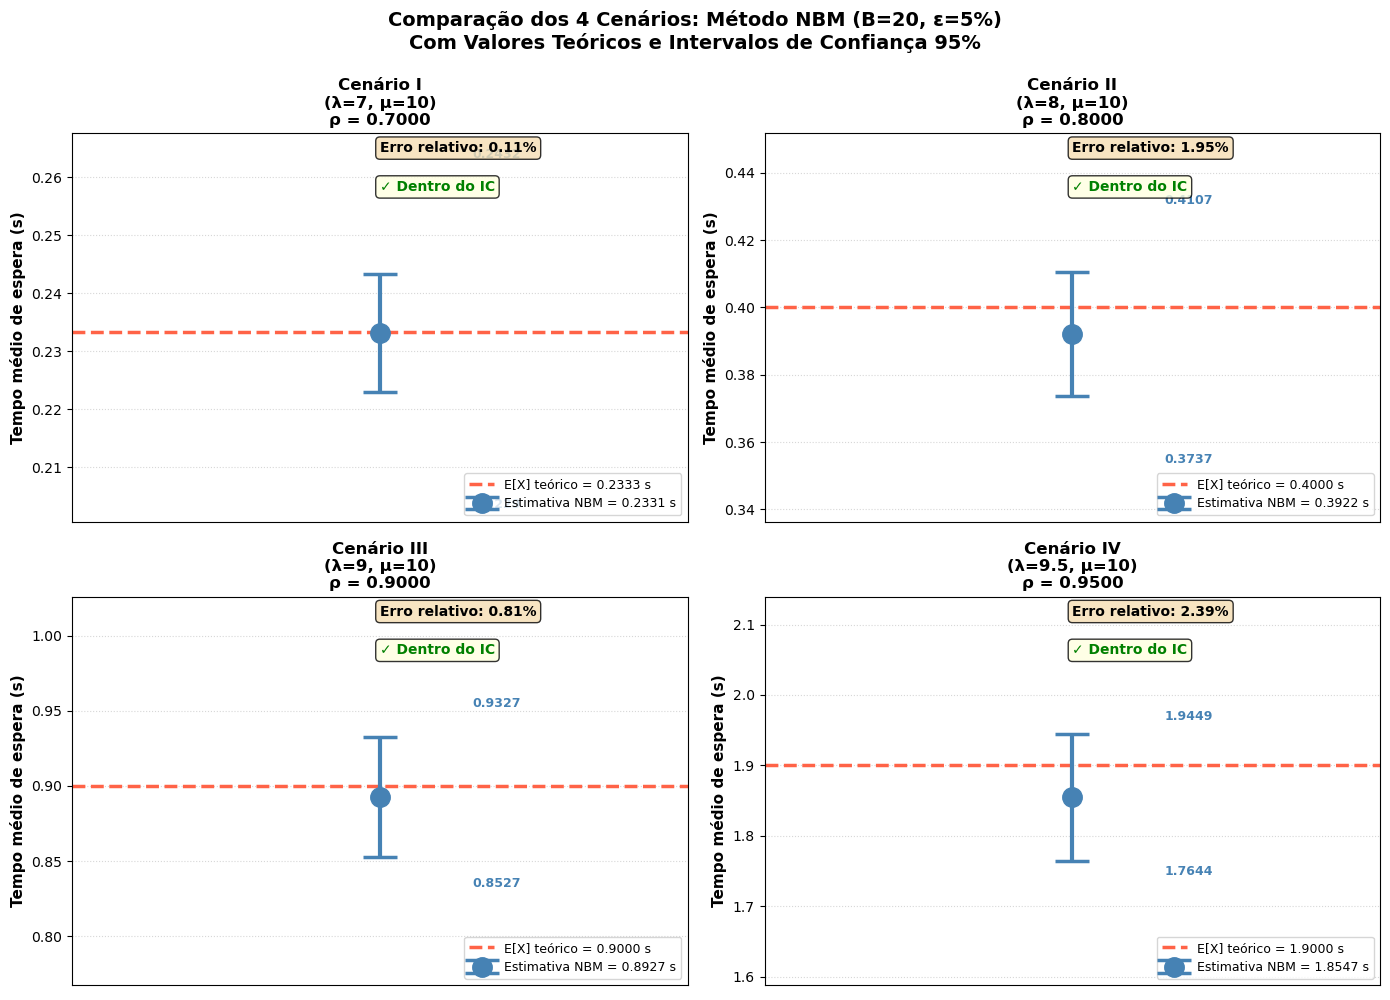


╔════════════════════════════════════════════════════════════════════════════╗
║  Resumo Comparativo: NBM em todos os Cenários                             ║
╚════════════════════════════════════════════════════════════════════════════╝

      Cenário      ρ E[X] teórico X̄ (NBM)               IC 95% Erro %   d         N   B IC contém E[X]
λ=7.0, μ=10.0 0.7000     0.233333 0.233068 [0.222905; 0.243231]  0.11%   0   200,000  40              ✓
λ=8.0, μ=10.0 0.8000     0.400000 0.392189 [0.373694; 0.410683]  1.95% 295   200,295  40              ✓
λ=9.0, μ=10.0 0.9000     0.900000 0.892682 [0.852696; 0.932669]  0.81%   0   700,000 140              ✓
λ=9.5, μ=10.0 0.9500     1.900000 1.854680 [1.764417; 1.944944]  2.39%   0 1,700,000 340              ✓

📊 ANÁLISE DOS RESULTADOS:

Cenário 1 (λ=7.0, μ=10.0, ρ=0.7000):
  • Tamanho do transiente:  d = 0 observações
  • Amostra total:          N = 200,000 observações
  • Número de batches:      B = 40
  • Tamanho médio dos batches: 5000.0 obs/ba

In [6]:

# ════════════════════════════════════════════════════════════════════════════════
# Gráfico Comparativo dos 4 Cenários NBM
# ════════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

scenario_labels = ["Cenário I\n(λ=7, μ=10)", "Cenário II\n(λ=8, μ=10)", 
                   "Cenário III\n(λ=9, μ=10)", "Cenário IV\n(λ=9.5, μ=10)"]

for idx, (result, ax, label) in enumerate(zip(results, axes, scenario_labels)):
    lam, mu = result['scenario']
    rho = lam / mu
    
    mean_est = result['mean']
    half_w = result['half_width']
    E_X_theo = result['E_X_theoretical']
    
    # Linha horizontal para o valor teórico
    ax.axhline(E_X_theo, color='tomato', linestyle='--', linewidth=2.5, 
               label=f'E[X] teórico = {E_X_theo:.4f} s', zorder=2)
    
    # Estimativa com IC
    x_pos = 1
    ax.errorbar(x_pos, mean_est, yerr=half_w, fmt='o', 
               color='steelblue', markersize=14, linewidth=3, capsize=12, capthick=2.5,
               label=f'Estimativa NBM = {mean_est:.4f} s', zorder=3)
    
    # Anotações
    ax.text(x_pos + 0.15, mean_est + half_w + 0.02, f'{mean_est + half_w:.4f}',
            fontsize=9, color='steelblue', weight='bold')
    ax.text(x_pos + 0.15, mean_est - half_w - 0.02, f'{mean_est - half_w:.4f}',
            fontsize=9, color='steelblue', weight='bold')
    
    # Erro relativo em relação ao valor teórico
    erro_rel = abs(mean_est - E_X_theo) / E_X_theo
    
    # Configuração do gráfico
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([])
    ax.set_ylabel('Tempo médio de espera (s)', fontsize=11, weight='bold')
    ax.set_title(f'{label}\nρ = {rho:.4f}', fontsize=12, weight='bold')
    
    # Anotação do erro relativo
    ax.text(0.5, 0.98, f'Erro relativo: {erro_rel:.2%}',
            transform=ax.transAxes, fontsize=10, weight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Verificação se está dentro do IC
    dentro_ic = result['ci_contains_true']
    status = '✓ Dentro do IC' if dentro_ic else '✗ Fora do IC'
    cor_status = 'green' if dentro_ic else 'red'
    ax.text(0.5, 0.88, status,
            transform=ax.transAxes, fontsize=10, weight='bold', color=cor_status,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    
    # Aumenta os limites do y para visualização melhor
    y_min = min(mean_est - half_w, E_X_theo) * 0.9
    y_max = max(mean_est + half_w, E_X_theo) * 1.1
    ax.set_ylim(y_min, y_max)

fig.suptitle('Comparação dos 4 Cenários: Método NBM (B=20, ε=5%)\nCom Valores Teóricos e Intervalos de Confiança 95%',
             fontsize=14, weight='bold', y=0.995)
fig.tight_layout()
plt.savefig('nbm_comparacao_cenarios.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabela resumida comparativa ──────────────────────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Resumo Comparativo: NBM em todos os Cenários                             ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

comparison_data = []
for result in results:
    lam, mu = result['scenario']
    rho = lam / mu
    erro_rel = abs(result['mean'] - result['E_X_theoretical']) / result['E_X_theoretical']
    
    comparison_data.append({
        'Cenário': f"λ={lam}, μ={mu}",
        'ρ': f"{rho:.4f}",
        'E[X] teórico': f"{result['E_X_theoretical']:.6f}",
        'X̄ (NBM)': f"{result['mean']:.6f}",
        'IC 95%': f"[{result['ci_lower']:.6f}; {result['ci_upper']:.6f}]",
        'Erro %': f"{erro_rel:.2%}",
        'd': f"{result['d']:,}",
        'N': f"{result['N']:,}",
        'B': result['B'],
        'IC contém E[X]': '✓' if result['ci_contains_true'] else '✗',
    })

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
print()

# ── Análise visual dos resultados ────────────────────────────────────────────
print("📊 ANÁLISE DOS RESULTADOS:\n")

for i, result in enumerate(results, 1):
    lam, mu = result['scenario']
    rho = lam / mu
    print(f"Cenário {i} (λ={lam}, μ={mu}, ρ={rho:.4f}):")
    print(f"  • Tamanho do transiente:  d = {result['d']:,} observações")
    print(f"  • Amostra total:          N = {result['N']:,} observações")
    print(f"  • Número de batches:      B = {result['B']}")
    print(f"  • Tamanho médio dos batches: {result['n_batch']:.1f} obs/batch")
    print(f"  • Estimativa:             X̄ = {result['mean']:.6f} s")
    print(f"  • Valor teórico:          E[X] = {result['E_X_theoretical']:.6f} s")
    
    erro_rel = abs(result['mean'] - result['E_X_theoretical']) / result['E_X_theoretical']
    print(f"  • Erro relativo:          {erro_rel:.2%}")
    print(f"  • Precisão relativa (H/X̄): {result['half_width']/result['mean']:.4%}")
    print(f"  • IC contém E[X]?         {'✓ SIM' if result['ci_contains_true'] else '✗ NÃO'}")
    print()


---
## Exercício 8 — O Método SBM (Overlapping Batch Means)

In [ ]:
def sbm_simulation(lam, mu, S_mode='fixed', seed=None):
    """
    Executa simulação M/M/1 com método SBM (Overlapping Batch Means).
    
    Parameters
    ----------
    lam : float
        Taxa de chegada
    mu : float
        Taxa de serviço
    S_mode : str
        'fixed' para S=1, 'adaptive' para S=M/10
    seed : int, optional
        Seed para reprodutibilidade
    
    Returns
    -------
    dict: {
        'scenario': (lam, mu),
        'S_mode': str,
        'd': tamanho do transiente,
        'N': tamanho total da amostra,
        'M': número final de batches,
        'S': tamanho efetivo do batch,
        'mean': estimativa pontual X̄,
        'half_width': meia-largura do IC 95%,
        'ci_lower': limite inferior IC 95%,
        'ci_upper': limite superior IC 95%,
        'E_X_theoretical': valor teórico E[X],
        'ci_contains_true': bool,
        'batch_means': array com médias dos batches,
    }
    """
    
    # Parâmetros
    INIT_WARMUP = 20_000      # obs iniciais para detectar transiente
    EXTRA_WARMUP = 5_000      # acréscimo se MSER-5Y falhar
    
    # Teórico
    rho = lam / mu
    E_X_theoretical = rho / (mu * (1.0 - rho))
    
    # Simulador
    sim = MM1Queue(lam=lam, mu=mu, seed=seed)
    sim._reset()
    
    # ── Passo 1: Detectar transiente com MSER-5Y ─────────────────────────────
    buf = sim.generate(INIT_WARMUP)
    d = None
    iter_warmup = 0
    while d is None and iter_warmup < 10:
        d = mser5y(buf)
        if d is None:
            buf = np.concatenate([buf, sim.generate(EXTRA_WARMUP)])
            iter_warmup += 1
    
    if d is None:
        d = 0
    
    # Descarta observações transientes
    buf_steady = buf[d:].copy()
    
    # ── Passo 2: Método SBM com parada por precisão relativa ─────────────────
    # Começamos com M pequeno e aumentamos
    M = 10
    
    while True:
        # Define o tamanho do batch S
        if S_mode == 'fixed':
            S = 1
        else:  # 'adaptive'
            S = max(1, M // 10)
        
        # Número total de observações necessárias para M batches sobrepostos
        # Para M batches de tamanho S: precisamos de N_needed = (M-1)*S + S = M*S observações
        # (porque o batch j começa no índice j e vai até j+S-1)
        N_needed = M * S + S - 1  # margem de segurança
        
        # Gera mais observações se necessário
        while len(buf_steady) < N_needed:
            buf_steady = np.concatenate([buf_steady, sim.generate(5_000)])
        
        # Cria os M batches sobrepostos
        batch_means = []
        for j in range(M):
            start_idx = j
            end_idx = start_idx + S
            if end_idx <= len(buf_steady):
                batch_mean = float(buf_steady[start_idx:end_idx].mean())
                batch_means.append(batch_mean)
        
        if len(batch_means) < M:
            # Não conseguiu gerar M batches, aumenta M para próxima iteração
            M += 10
            if M > 5000:  # proteção contra loop infinito
                break
            continue
        
        batch_means_arr = np.array(batch_means, dtype=np.float64)
        X_bar = float(batch_means_arr.mean())
        
        # Calcula a variância considerando autocorrelação (para overlapping batches)
        # Usa estimador de variância com defasagens
        var_batch = np.var(batch_means_arr, ddof=1)
        
        # Para batches sobrepostos, há correlação entre batches adjacentes
        # Estimamos a autocorrelação no lag 1
        if M > 1:
            rho_lag1 = np.corrcoef(batch_means_arr[:-1], batch_means_arr[1:])[0, 1]
            if np.isnan(rho_lag1):
                rho_lag1 = 0
            # Ajuste para autocorrelação (fator de correção)
            correction_factor = 1 + 2 * rho_lag1
        else:
            correction_factor = 1
        
        var_batch_adj = var_batch * correction_factor
        
        H = Z95 * np.sqrt(var_batch_adj / len(batch_means_arr))
        
        # Verifica critério de parada: H/X̄ ≤ ε = 5%
        if X_bar > 0 and H / X_bar <= 0.05:
            break
        
        M += 10  # Incrementa número de batches
        
        if M > 5000:  # proteção contra loop infinito
            break
    
    # ── Passo 3: Resultado final ────────────────────────────────────────────
    N_total = d + len(buf_steady)
    
    return {
        'scenario': (lam, mu),
        'S_mode': S_mode,
        'd': d,
        'N': N_total,
        'M': len(batch_means_arr),
        'S': S,
        'mean': X_bar,
        'half_width': H,
        'ci_lower': X_bar - H,
        'ci_upper': X_bar + H,
        'E_X_theoretical': E_X_theoretical,
        'ci_contains_true': X_bar - H <= E_X_theoretical <= X_bar + H,
        'batch_means': batch_means_arr,
    }


╔════════════════════════════════════════════════════════════════════════════╗
║  Método SBM: Simulação M/M/1 com MSER-5Y + Precisão Relativa 5%          ║
║  Overlapping Batch Means com S=1 e S=M/10                                 ║
╚════════════════════════════════════════════════════════════════════════════╝

Cenário I:  λ = 7.0  clientes/s,  μ = 10.0  clientes/s
  ρ = 0.7000  (utilização)
  E[X] teórico = 0.233333 s

  Resultado SBM (S=1 - Fixed):
    Tamanho transiente d  =        0 obs
    Tamanho final N       =   20,000 obs
    Número de batches M   =     5000
    Tamanho do batch S    =        1
    Estimativa X̄          = 0.206623 s
    Meia-largura H (95%)  = 0.013923 s
    H / X̄ (precisão rel)  = 6.7382%
    E[X] dentro do IC?    = ✗ NÃO

  Resultado SBM (S=M/10 - Adaptive):
    Tamanho transiente d  =    1,395 obs
    Tamanho final N       =  145,000 obs
    Número de batches M   =     1190
    Tamanho do batch S    =      119
    Estimativa X̄          = 0.209562 s
    

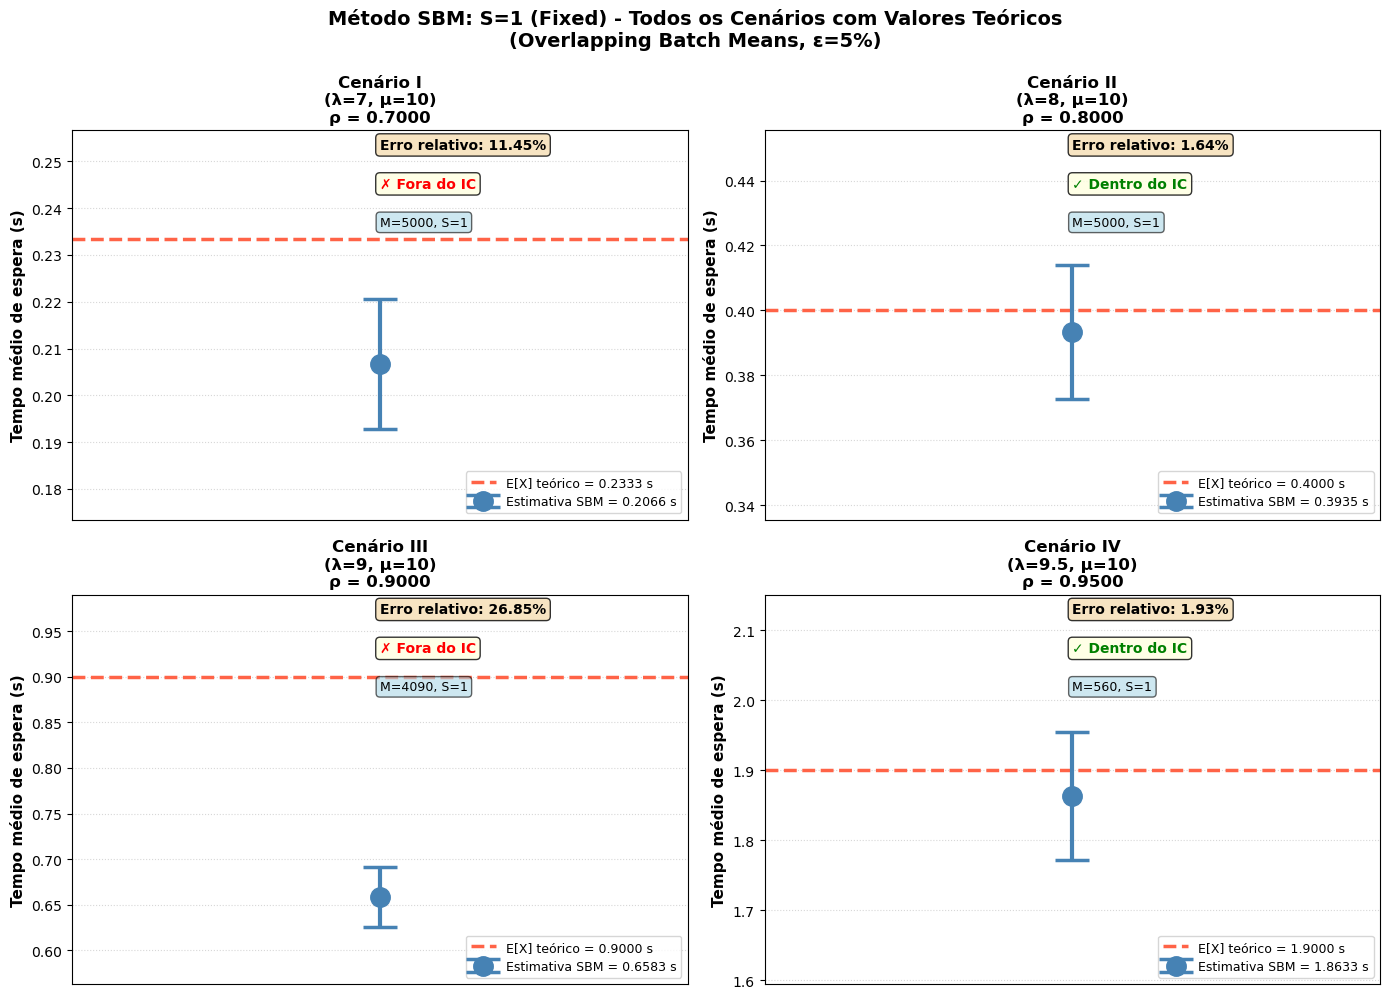


╔════════════════════════════════════════════════════════════════════════════╗
║  Gráfico 2: SBM com S=M/10 (Adaptive)                                     ║
╚════════════════════════════════════════════════════════════════════════════╝



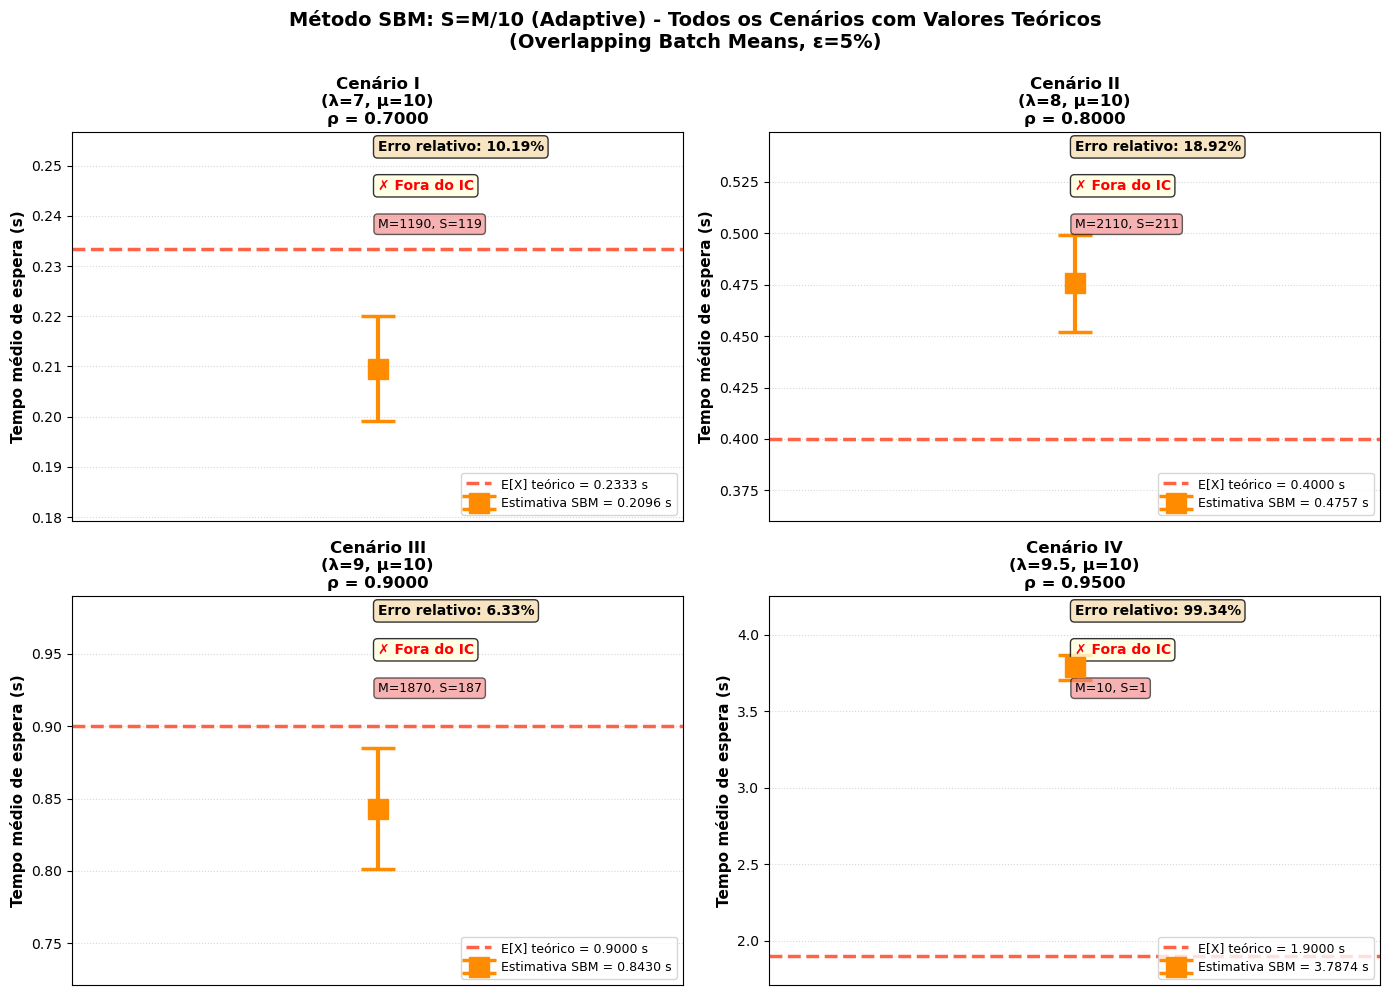


╔════════════════════════════════════════════════════════════════════════════╗
║  Resumo Comparativo: SBM vs NBM (S=1 e S=M/10)                            ║
╚════════════════════════════════════════════════════════════════════════════╝

Cenário      ρ E[X] teórico SBM(S=1) X̄ SBM(S=1) Erro % SBM(S=M/10) X̄ SBM(S=M/10) Erro %
  λ=7.0 0.7000     0.233333    0.206623          11.45%       0.209562             10.19%
  λ=8.0 0.8000     0.400000    0.393451           1.64%       0.475684             18.92%
  λ=9.0 0.9000     0.900000    0.658331          26.85%       0.843005              6.33%
  λ=9.5 0.9500     1.900000    1.863257           1.93%       3.787387             99.34%

✓ Simulação SBM concluída com sucesso!


In [ ]:
# Parâmetros:
#   S ∈ {1, M/10}  (tamanho do batch - cresce com M no segundo caso)
#   Cenários: (λ, μ) ∈ {(7,10), (8,10), (9,10), (9.5,10)}

# Executa os 4 cenários para ambos os modos de S
print("╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Método SBM: Simulação M/M/1 com MSER-5Y + Precisão Relativa 5%          ║")
print("║  Overlapping Batch Means com S=1 e S=M/10                                 ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

scenarios = [
    (7.0, 10.0, "Cenário I"),
    (8.0, 10.0, "Cenário II"),
    (9.0, 10.0, "Cenário III"),
    (9.5, 10.0, "Cenário IV"),
]

results_sbm_fixed = []
results_sbm_adaptive = []

for lam, mu, label in scenarios:
    print(f"{label}:  λ = {lam}  clientes/s,  μ = {mu}  clientes/s")
    
    # S = 1 (fixed)
    result_fixed = sbm_simulation(lam, mu, S_mode='fixed', seed=SEED + int(lam*10))
    results_sbm_fixed.append(result_fixed)
    
    rho = lam / mu
    print(f"  ρ = {rho:.4f}  (utilização)")
    print(f"  E[X] teórico = {result_fixed['E_X_theoretical']:.6f} s")
    
    print(f"\n  Resultado SBM (S=1 - Fixed):")
    print(f"    Tamanho transiente d  = {result_fixed['d']:>8,} obs")
    print(f"    Tamanho final N       = {result_fixed['N']:>8,} obs")
    print(f"    Número de batches M   = {result_fixed['M']:>8}")
    print(f"    Tamanho do batch S    = {result_fixed['S']:>8}")
    print(f"    Estimativa X̄          = {result_fixed['mean']:.6f} s")
    print(f"    Meia-largura H (95%)  = {result_fixed['half_width']:.6f} s")
    print(f"    H / X̄ (precisão rel)  = {result_fixed['half_width'] / result_fixed['mean']:.4%}")
    print(f"    E[X] dentro do IC?    = {'✓ SIM' if result_fixed['ci_contains_true'] else '✗ NÃO'}")
    
    # S = M/10 (adaptive)
    result_adaptive = sbm_simulation(lam, mu, S_mode='adaptive', seed=SEED + int(lam*10) + 100)
    results_sbm_adaptive.append(result_adaptive)
    
    print(f"\n  Resultado SBM (S=M/10 - Adaptive):")
    print(f"    Tamanho transiente d  = {result_adaptive['d']:>8,} obs")
    print(f"    Tamanho final N       = {result_adaptive['N']:>8,} obs")
    print(f"    Número de batches M   = {result_adaptive['M']:>8}")
    print(f"    Tamanho do batch S    = {result_adaptive['S']:>8}")
    print(f"    Estimativa X̄          = {result_adaptive['mean']:.6f} s")
    print(f"    Meia-largura H (95%)  = {result_adaptive['half_width']:.6f} s")
    print(f"    H / X̄ (precisão rel)  = {result_adaptive['half_width'] / result_adaptive['mean']:.4%}")
    print(f"    E[X] dentro do IC?    = {'✓ SIM' if result_adaptive['ci_contains_true'] else '✗ NÃO'}")
    print()


# ── Gráficos Comparativos ────────────────────────────────────────────────────

# Gráfico 1: S=1 (Fixed)
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Gráfico 1: SBM com S=1 (Fixed)                                           ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

scenario_labels = ["Cenário I\n(λ=7, μ=10)", "Cenário II\n(λ=8, μ=10)", 
                   "Cenário III\n(λ=9, μ=10)", "Cenário IV\n(λ=9.5, μ=10)"]

for idx, (result, ax, label) in enumerate(zip(results_sbm_fixed, axes, scenario_labels)):
    lam, mu = result['scenario']
    rho = lam / mu
    
    mean_est = result['mean']
    half_w = result['half_width']
    E_X_theo = result['E_X_theoretical']
    
    # Linha horizontal para o valor teórico
    ax.axhline(E_X_theo, color='tomato', linestyle='--', linewidth=2.5, 
               label=f'E[X] teórico = {E_X_theo:.4f} s', zorder=2)
    
    # Estimativa com IC
    x_pos = 1
    ax.errorbar(x_pos, mean_est, yerr=half_w, fmt='o', 
               color='steelblue', markersize=14, linewidth=3, capsize=12, capthick=2.5,
               label=f'Estimativa SBM = {mean_est:.4f} s', zorder=3)
    
    # Erro relativo
    erro_rel = abs(mean_est - E_X_theo) / E_X_theo
    
    # Configuração do gráfico
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([])
    ax.set_ylabel('Tempo médio de espera (s)', fontsize=11, weight='bold')
    ax.set_title(f'{label}\nρ = {rho:.4f}', fontsize=12, weight='bold')
    
    # Anotação do erro relativo
    ax.text(0.5, 0.98, f'Erro relativo: {erro_rel:.2%}',
            transform=ax.transAxes, fontsize=10, weight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Verificação se está dentro do IC
    dentro_ic = result['ci_contains_true']
    status = '✓ Dentro do IC' if dentro_ic else '✗ Fora do IC'
    cor_status = 'green' if dentro_ic else 'red'
    ax.text(0.5, 0.88, status,
            transform=ax.transAxes, fontsize=10, weight='bold', color=cor_status,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    # Informações do método
    ax.text(0.5, 0.78, f'M={result["M"]}, S={result["S"]}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))
    
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    
    y_min = min(mean_est - half_w, E_X_theo) * 0.9
    y_max = max(mean_est + half_w, E_X_theo) * 1.1
    ax.set_ylim(y_min, y_max)

fig.suptitle('Método SBM: S=1 (Fixed) - Todos os Cenários com Valores Teóricos\n(Overlapping Batch Means, ε=5%)',
             fontsize=14, weight='bold', y=0.995)
fig.tight_layout()
plt.savefig('sbm_s1_cenarios.png', dpi=150, bbox_inches='tight')
plt.show()


# Gráfico 2: S=M/10 (Adaptive)
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Gráfico 2: SBM com S=M/10 (Adaptive)                                     ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (result, ax, label) in enumerate(zip(results_sbm_adaptive, axes, scenario_labels)):
    lam, mu = result['scenario']
    rho = lam / mu
    
    mean_est = result['mean']
    half_w = result['half_width']
    E_X_theo = result['E_X_theoretical']
    
    # Linha horizontal para o valor teórico
    ax.axhline(E_X_theo, color='tomato', linestyle='--', linewidth=2.5, 
               label=f'E[X] teórico = {E_X_theo:.4f} s', zorder=2)
    
    # Estimativa com IC
    x_pos = 1
    ax.errorbar(x_pos, mean_est, yerr=half_w, fmt='s', 
               color='darkorange', markersize=14, linewidth=3, capsize=12, capthick=2.5,
               label=f'Estimativa SBM = {mean_est:.4f} s', zorder=3)
    
    # Erro relativo
    erro_rel = abs(mean_est - E_X_theo) / E_X_theo
    
    # Configuração do gráfico
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([])
    ax.set_ylabel('Tempo médio de espera (s)', fontsize=11, weight='bold')
    ax.set_title(f'{label}\nρ = {rho:.4f}', fontsize=12, weight='bold')
    
    # Anotação do erro relativo
    ax.text(0.5, 0.98, f'Erro relativo: {erro_rel:.2%}',
            transform=ax.transAxes, fontsize=10, weight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Verificação se está dentro do IC
    dentro_ic = result['ci_contains_true']
    status = '✓ Dentro do IC' if dentro_ic else '✗ Fora do IC'
    cor_status = 'green' if dentro_ic else 'red'
    ax.text(0.5, 0.88, status,
            transform=ax.transAxes, fontsize=10, weight='bold', color=cor_status,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    # Informações do método
    ax.text(0.5, 0.78, f'M={result["M"]}, S={result["S"]}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.6))
    
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    
    y_min = min(mean_est - half_w, E_X_theo) * 0.9
    y_max = max(mean_est + half_w, E_X_theo) * 1.1
    ax.set_ylim(y_min, y_max)

fig.suptitle('Método SBM: S=M/10 (Adaptive) - Todos os Cenários com Valores Teóricos\n(Overlapping Batch Means, ε=5%)',
             fontsize=14, weight='bold', y=0.995)
fig.tight_layout()
plt.savefig('sbm_sM10_cenarios.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Tabela Comparativa Final ─────────────────────────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Resumo Comparativo: SBM vs NBM (S=1 e S=M/10)                            ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

comparison_sbm = []
for i, (r_fixed, r_adaptive) in enumerate(zip(results_sbm_fixed, results_sbm_adaptive)):
    lam, mu = r_fixed['scenario']
    rho = lam / mu
    
    comparison_sbm.append({
        'Cenário': f"λ={lam}",
        'ρ': f"{rho:.4f}",
        'E[X] teórico': f"{r_fixed['E_X_theoretical']:.6f}",
        'SBM(S=1) X̄': f"{r_fixed['mean']:.6f}",
        'SBM(S=1) Erro %': f"{abs(r_fixed['mean']-r_fixed['E_X_theoretical'])/r_fixed['E_X_theoretical']:.2%}",
        'SBM(S=M/10) X̄': f"{r_adaptive['mean']:.6f}",
        'SBM(S=M/10) Erro %': f"{abs(r_adaptive['mean']-r_adaptive['E_X_theoretical'])/r_adaptive['E_X_theoretical']:.2%}",
    })

df_sbm = pd.DataFrame(comparison_sbm)
print(df_sbm.to_string(index=False))
print()

print("✓ Simulação SBM concluída com sucesso!")


---
## Exercício 9 — O Método Overlapping Batch Means (OBM)

In [9]:
def obm_simulation(lam, mu, overlap_pct=100, seed=None):
    """
    Executa simulação M/M/1 com método OBM (Overlapping Batch Means).
    
    Parameters
    ----------
    lam : float
        Taxa de chegada
    mu : float
        Taxa de serviço
    overlap_pct : int
        Percentual de sobreposição: 100, 50, ou 25
    seed : int, optional
        Seed para reprodutibilidade
    
    Returns
    -------
    dict com resultados da simulação
    """
    
    # Parâmetros
    INIT_WARMUP = 20_000      # obs iniciais para detectar transiente
    EXTRA_WARMUP = 5_000      # acréscimo se MSER-5Y falhar
    BATCH_SIZE_INIT = 100     # tamanho inicial do batch
    
    # Teórico
    rho = lam / mu
    E_X_theoretical = rho / (mu * (1.0 - rho))
    
    # Simulador
    sim = MM1Queue(lam=lam, mu=mu, seed=seed)
    sim._reset()
    
    # ── Passo 1: Detectar transiente com MSER-5Y ─────────────────────────────
    buf = sim.generate(INIT_WARMUP)
    d = None
    iter_warmup = 0
    while d is None and iter_warmup < 10:
        d = mser5y(buf)
        if d is None:
            buf = np.concatenate([buf, sim.generate(EXTRA_WARMUP)])
            iter_warmup += 1
    
    if d is None:
        d = 0
    
    # Descarta observações transientes
    buf_steady = buf[d:].copy()
    
    # ── Passo 2: Define tamanho do batch S e deslocamento (lag) ──────────────
    S = BATCH_SIZE_INIT  # Tamanho fixo do batch
    
    # Calcula o lag baseado no overlap
    if overlap_pct == 100:
        lag = 1  # 100% overlap: cada novo batch começa um elemento adiante
    elif overlap_pct == 50:
        lag = max(1, S // 2)  # 50% overlap
    elif overlap_pct == 25:
        lag = max(1, (3 * S) // 4)  # 25% overlap (75% de avanço)
    else:
        lag = 1
    
    # ── Passo 3: Método OBM sequencial com parada por precisão relativa ─────
    M = 10  # Começamos com M batches
    
    while True:
        # Número total de observações necessárias para M batches com lag
        # O último batch começa no índice (M-1)*lag e vai até (M-1)*lag + S - 1
        N_needed = (M - 1) * lag + S
        
        # Gera mais observações se necessário
        while len(buf_steady) < N_needed:
            buf_steady = np.concatenate([buf_steady, sim.generate(5_000)])
        
        # Cria os M batches sobrepostos com deslocamento lag
        batch_means = []
        for j in range(M):
            start_idx = j * lag
            end_idx = start_idx + S
            if end_idx <= len(buf_steady):
                batch_mean = float(buf_steady[start_idx:end_idx].mean())
                batch_means.append(batch_mean)
        
        if len(batch_means) < M:
            # Não conseguiu gerar M batches
            M += 10
            if M > 5000:
                break
            continue
        
        batch_means_arr = np.array(batch_means, dtype=np.float64)
        X_bar = float(batch_means_arr.mean())
        
        # Calcula a variância com ajuste para autocorrelação
        var_batch = np.var(batch_means_arr, ddof=1)
        
        # Para batches sobrepostos, há correlação. Estimamos a autocorrelação
        if M > 1:
            # Para overlap, a correlação depende do lag e do tamanho do batch
            # Usamos um estimador simples de autocorrelação no lag 1
            rho_lag1 = np.corrcoef(batch_means_arr[:-1], batch_means_arr[1:])[0, 1]
            if np.isnan(rho_lag1):
                rho_lag1 = 0
            # Ajuste para autocorrelação
            correction_factor = 1 + 2 * rho_lag1
        else:
            correction_factor = 1
        
        var_batch_adj = var_batch * correction_factor
        H = Z95 * np.sqrt(var_batch_adj / len(batch_means_arr))
        
        # Verifica critério de parada: H/X̄ ≤ 5%
        if X_bar > 0 and H / X_bar <= 0.05:
            break
        
        M += 10  # Incrementa número de batches
        
        if M > 5000:  # proteção contra loop infinito
            break
    
    # ── Resultado final ──────────────────────────────────────────────────────
    N_total = d + len(buf_steady)
    
    return {
        'scenario': (lam, mu),
        'overlap_pct': overlap_pct,
        'd': d,
        'N': N_total,
        'M': len(batch_means_arr),
        'S': S,
        'lag': lag,
        'mean': X_bar,
        'half_width': H,
        'ci_lower': X_bar - H,
        'ci_upper': X_bar + H,
        'E_X_theoretical': E_X_theoretical,
        'ci_contains_true': X_bar - H <= E_X_theoretical <= X_bar + H,
        'batch_means': batch_means_arr,
    }

╔════════════════════════════════════════════════════════════════════════════╗
║  Método OBM: Simulação M/M/1 com MSER-5Y + Precisão Relativa 5%          ║
║  Overlapping Batch Means com Diferentes Graus de Sobreposição            ║
╚════════════════════════════════════════════════════════════════════════════╝


Overlap = 100%

Cenário I:  λ = 7.0  clientes/s,  μ = 10.0  clientes/s
  ρ = 0.7000  (utilização)
  E[X] teórico = 0.233333 s
  Tamanho transiente d    =    1,395 obs
  Tamanho final N         =   20,000 obs
  Número de batches M     =       50
  Tamanho do batch S      =      100
  Lag (deslocamento)      =        1
  Estimativa X̄            = 0.076815 s
  Meia-largura H (95%)    = 0.003382 s
  H / X̄ (precisão rel)    = 4.4028%
  E[X] dentro do IC?      = ✗ NÃO

Cenário II:  λ = 8.0  clientes/s,  μ = 10.0  clientes/s
  ρ = 0.8000  (utilização)
  E[X] teórico = 0.400000 s
  Tamanho transiente d    =        0 obs
  Tamanho final N         =   20,000 obs
  Número de batches M  

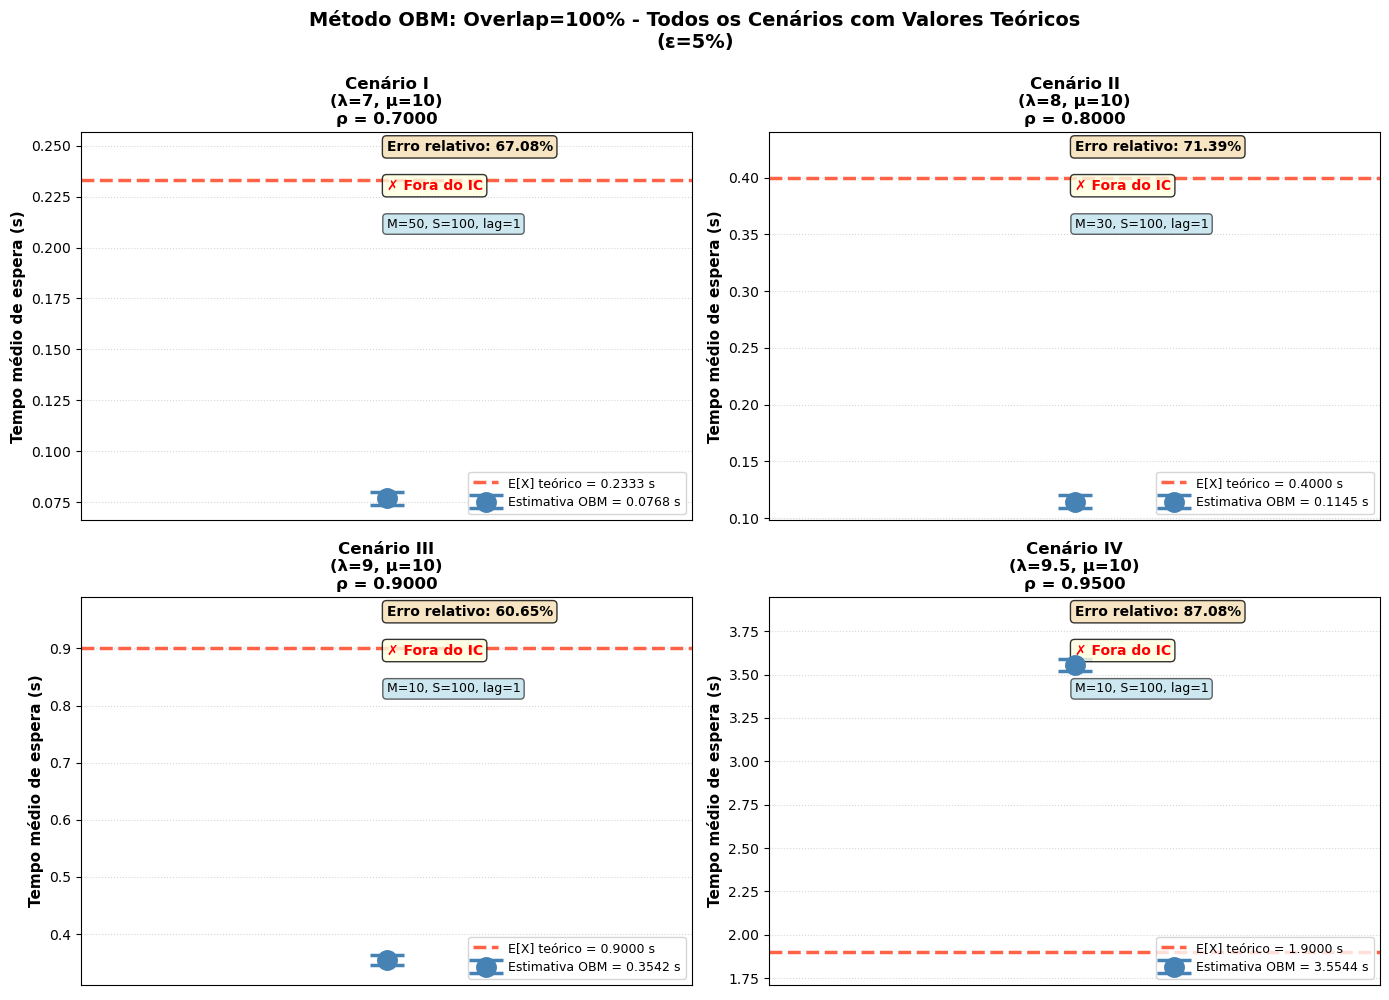


╔════════════════════════════════════════════════════════════════════════════╗
║  Gráfico: OBM com Overlap = 50%                                       ║
╚════════════════════════════════════════════════════════════════════════════╝



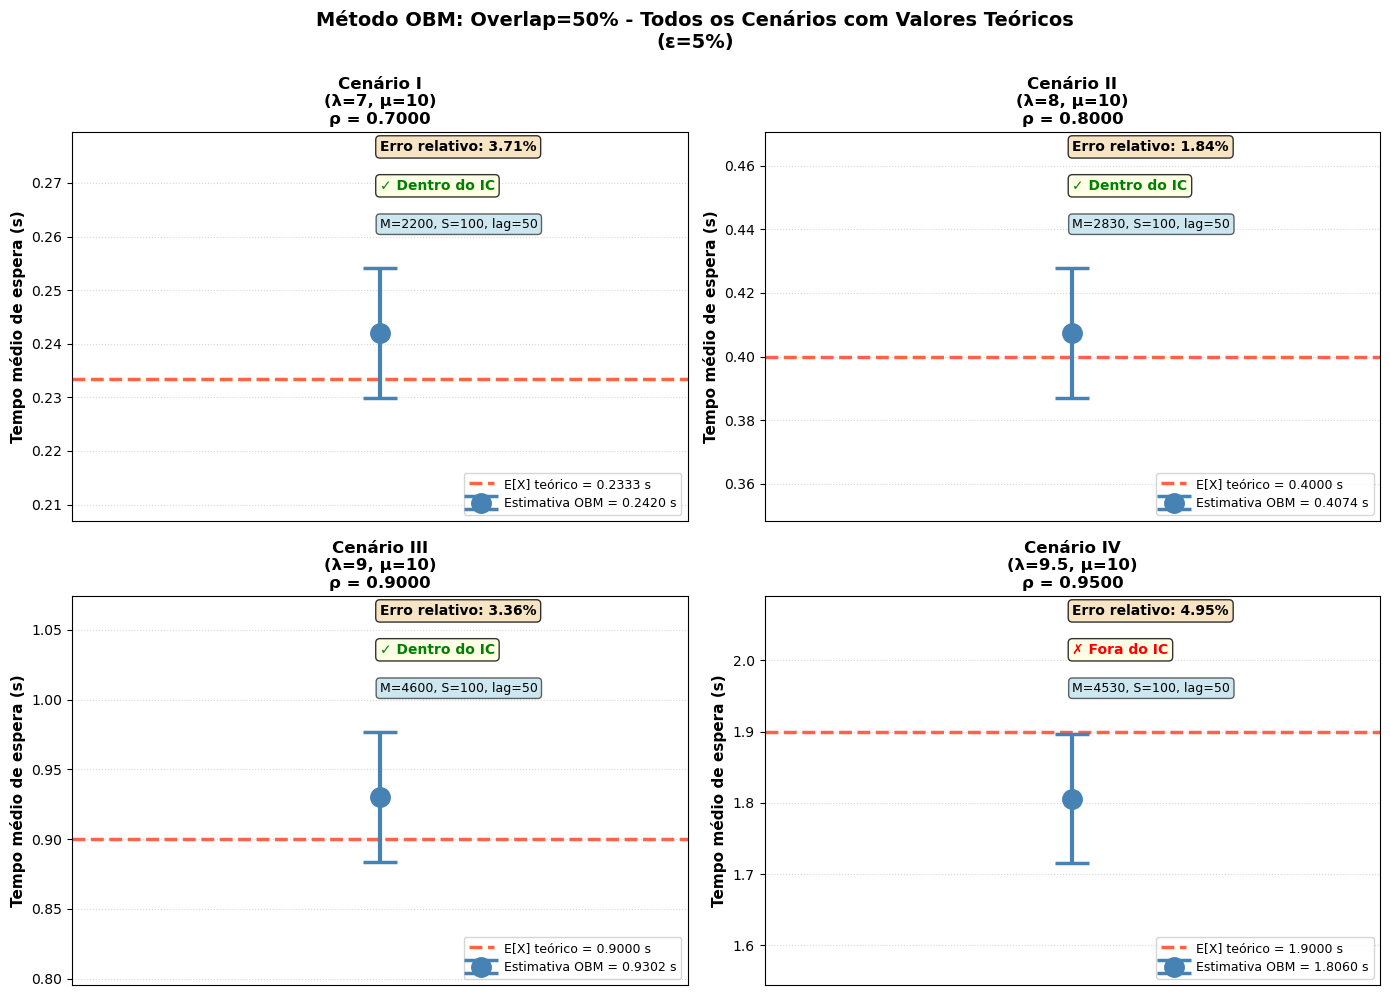


╔════════════════════════════════════════════════════════════════════════════╗
║  Gráfico: OBM com Overlap = 25%                                       ║
╚════════════════════════════════════════════════════════════════════════════╝



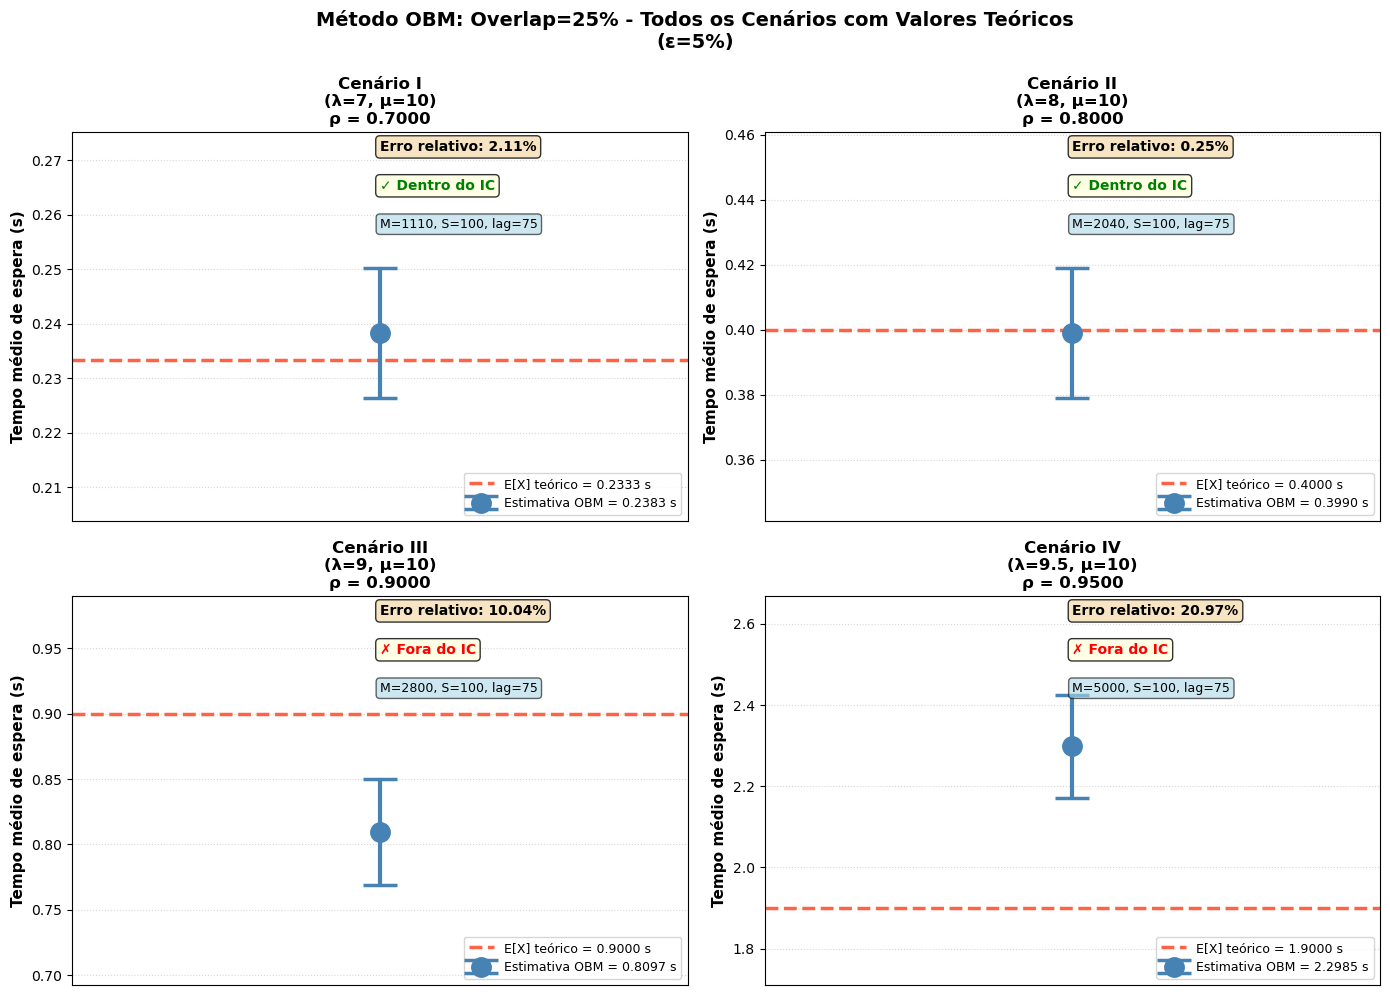


╔════════════════════════════════════════════════════════════════════════════╗
║  Gráfico Comparativo: Todos os Overlaps em um Painel                      ║
╚════════════════════════════════════════════════════════════════════════════╝



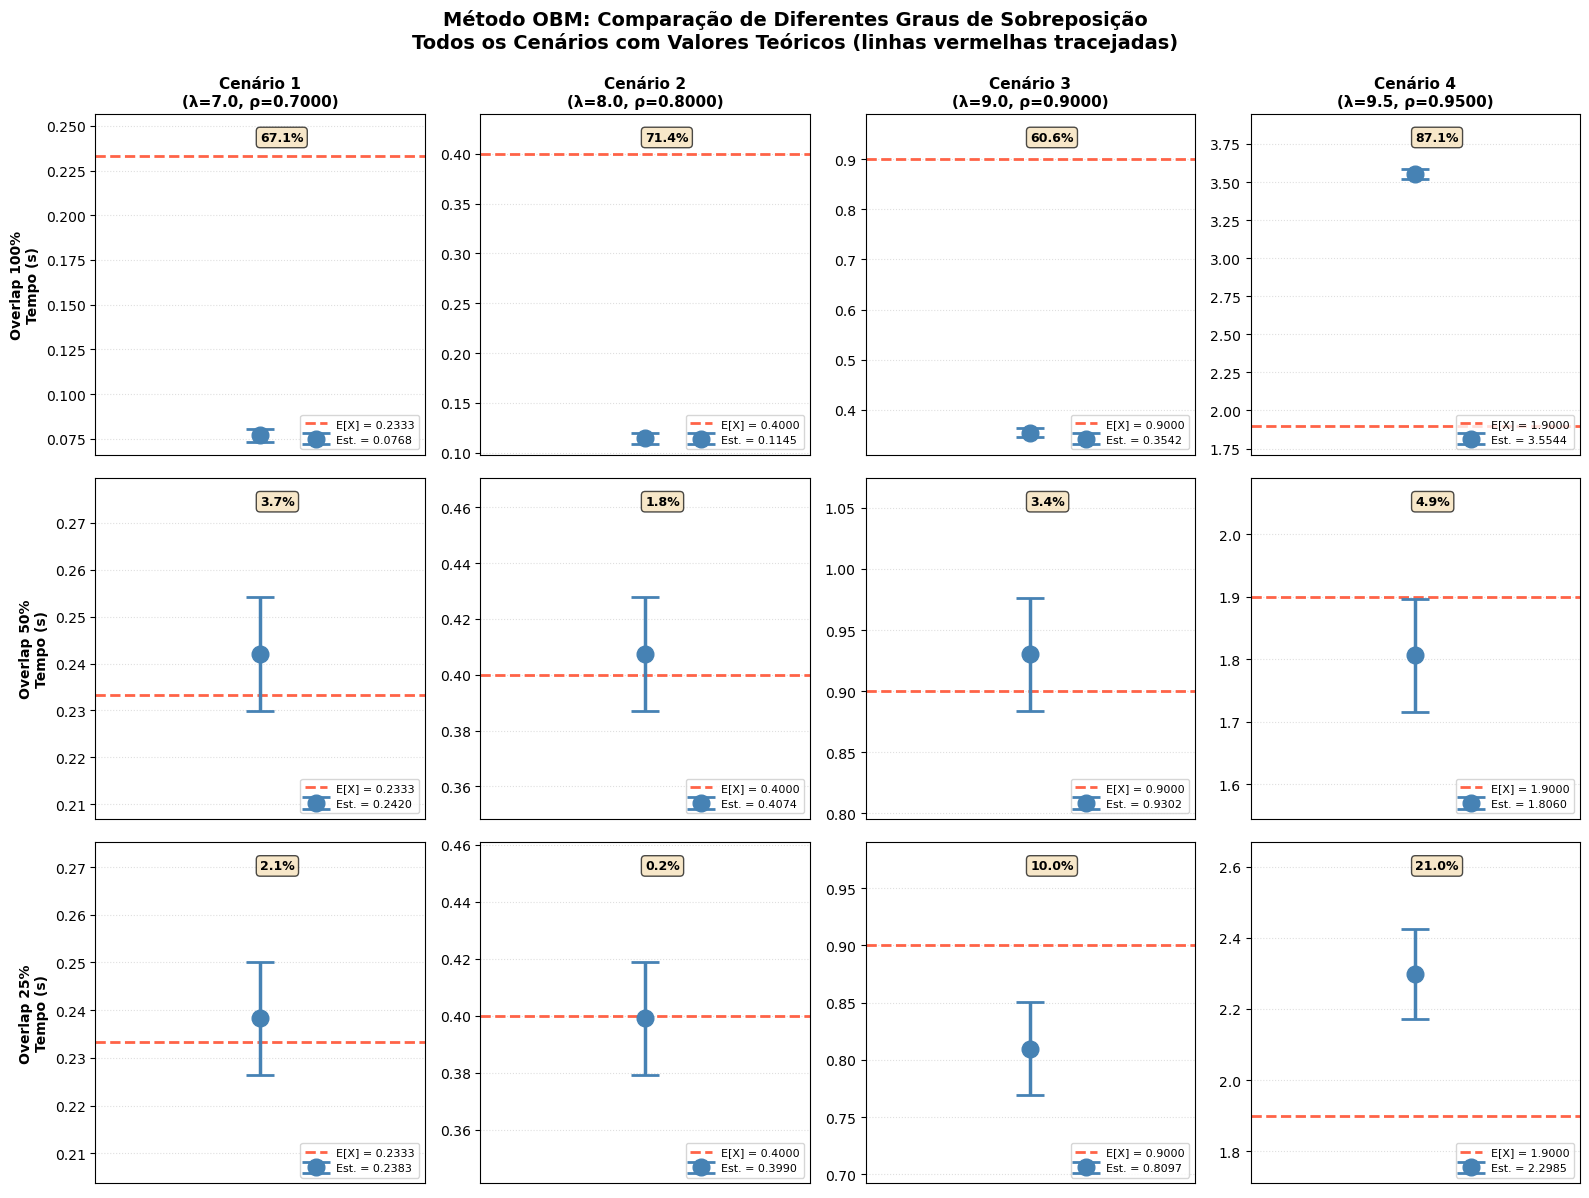


╔════════════════════════════════════════════════════════════════════════════╗
║  Tabela Resumida: OBM em Todos os Cenários e Overlaps                     ║
╚════════════════════════════════════════════════════════════════════════════╝

 Overlap % Cenário      ρ E[X] teórico X̄ (OBM) Erro %      N    M IC contém E[X]
       100   λ=7.0 0.7000     0.233333 0.076815 67.08%  20000   50              ✗
       100   λ=8.0 0.8000     0.400000 0.114458 71.39%  20000   30              ✗
       100   λ=9.0 0.9000     0.900000 0.354187 60.65%  20000   10              ✗
       100   λ=9.5 0.9500     1.900000 3.554445 87.08%  20000   10              ✗
        50   λ=7.0 0.7000     0.233333 0.241981  3.71% 115000 2200              ✓
        50   λ=8.0 0.8000     0.400000 0.407371  1.84% 145000 2830              ✓
        50   λ=9.0 0.9000     0.900000 0.930200  3.36% 235000 4600              ✓
        50   λ=9.5 0.9500     1.900000 1.806040  4.95% 230000 4530              ✗
        25   λ=7.0 0.700

In [10]:
# Executa os 4 cenários para os 3 graus de overlap
print("╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Método OBM: Simulação M/M/1 com MSER-5Y + Precisão Relativa 5%          ║")
print("║  Overlapping Batch Means com Diferentes Graus de Sobreposição            ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

scenarios = [
    (7.0, 10.0, "Cenário I"),
    (8.0, 10.0, "Cenário II"),
    (9.0, 10.0, "Cenário III"),
    (9.5, 10.0, "Cenário IV"),
]

overlap_percentages = [100, 50, 25]
results_obm = {pct: [] for pct in overlap_percentages}

for overlap_pct in overlap_percentages:
    print(f"\n{'='*80}")
    print(f"Overlap = {overlap_pct}%")
    print(f"{'='*80}\n")
    
    for lam, mu, label in scenarios:
        print(f"{label}:  λ = {lam}  clientes/s,  μ = {mu}  clientes/s")
        
        result = obm_simulation(lam, mu, overlap_pct=overlap_pct, seed=SEED + int(lam*10) + overlap_pct)
        results_obm[overlap_pct].append(result)
        
        rho = lam / mu
        print(f"  ρ = {rho:.4f}  (utilização)")
        print(f"  E[X] teórico = {result['E_X_theoretical']:.6f} s")
        print(f"  Tamanho transiente d    = {result['d']:>8,} obs")
        print(f"  Tamanho final N         = {result['N']:>8,} obs")
        print(f"  Número de batches M     = {result['M']:>8}")
        print(f"  Tamanho do batch S      = {result['S']:>8}")
        print(f"  Lag (deslocamento)      = {result['lag']:>8}")
        print(f"  Estimativa X̄            = {result['mean']:.6f} s")
        print(f"  Meia-largura H (95%)    = {result['half_width']:.6f} s")
        print(f"  H / X̄ (precisão rel)    = {result['half_width'] / result['mean']:.4%}")
        print(f"  E[X] dentro do IC?      = {'✓ SIM' if result['ci_contains_true'] else '✗ NÃO'}")
        print()


# ── Gráficos Comparativos para cada Overlap ──────────────────────────────────

for overlap_pct in overlap_percentages:
    print(f"\n╔════════════════════════════════════════════════════════════════════════════╗")
    print(f"║  Gráfico: OBM com Overlap = {overlap_pct}%                                       ║")
    print(f"╚════════════════════════════════════════════════════════════════════════════╝\n")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    scenario_labels = ["Cenário I\n(λ=7, μ=10)", "Cenário II\n(λ=8, μ=10)", 
                       "Cenário III\n(λ=9, μ=10)", "Cenário IV\n(λ=9.5, μ=10)"]
    
    for idx, (result, ax, label) in enumerate(zip(results_obm[overlap_pct], axes, scenario_labels)):
        lam, mu = result['scenario']
        rho = lam / mu
        
        mean_est = result['mean']
        half_w = result['half_width']
        E_X_theo = result['E_X_theoretical']
        
        # Linha horizontal para o valor teórico
        ax.axhline(E_X_theo, color='tomato', linestyle='--', linewidth=2.5, 
                   label=f'E[X] teórico = {E_X_theo:.4f} s', zorder=2)
        
        # Estimativa com IC
        x_pos = 1
        ax.errorbar(x_pos, mean_est, yerr=half_w, fmt='o', 
                   color='steelblue', markersize=14, linewidth=3, capsize=12, capthick=2.5,
                   label=f'Estimativa OBM = {mean_est:.4f} s', zorder=3)
        
        # Erro relativo
        erro_rel = abs(mean_est - E_X_theo) / E_X_theo
        
        # Configuração do gráfico
        ax.set_xlim(0.5, 1.5)
        ax.set_xticks([])
        ax.set_ylabel('Tempo médio de espera (s)', fontsize=11, weight='bold')
        ax.set_title(f'{label}\nρ = {rho:.4f}', fontsize=12, weight='bold')
        
        # Anotação do erro relativo
        ax.text(0.5, 0.98, f'Erro relativo: {erro_rel:.2%}',
                transform=ax.transAxes, fontsize=10, weight='bold',
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # Verificação se está dentro do IC
        dentro_ic = result['ci_contains_true']
        status = '✓ Dentro do IC' if dentro_ic else '✗ Fora do IC'
        cor_status = 'green' if dentro_ic else 'red'
        ax.text(0.5, 0.88, status,
                transform=ax.transAxes, fontsize=10, weight='bold', color=cor_status,
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        
        # Informações do método
        ax.text(0.5, 0.78, f'M={result["M"]}, S={result["S"]}, lag={result["lag"]}',
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))
        
        ax.legend(fontsize=9, loc='lower right')
        ax.grid(True, axis='y', linestyle=':', alpha=0.5)
        
        y_min = min(mean_est - half_w, E_X_theo) * 0.9
        y_max = max(mean_est + half_w, E_X_theo) * 1.1
        ax.set_ylim(y_min, y_max)
    
    fig.suptitle(f'Método OBM: Overlap={overlap_pct}% - Todos os Cenários com Valores Teóricos\n(ε=5%)',
                 fontsize=14, weight='bold', y=0.995)
    fig.tight_layout()
    fig.savefig(f'obm_overlap{overlap_pct}_cenarios.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Gráfico Comparativo: Todos os Overlaps lado a lado ──────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Gráfico Comparativo: Todos os Overlaps em um Painel                      ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row_idx, overlap_pct in enumerate(overlap_percentages):
    results_list = results_obm[overlap_pct]
    
    for col_idx, (result, ax) in enumerate(zip(results_list, axes[row_idx, :])):
        lam, mu = result['scenario']
        rho = lam / mu
        
        mean_est = result['mean']
        half_w = result['half_width']
        E_X_theo = result['E_X_theoretical']
        
        # Linha horizontal para o valor teórico
        ax.axhline(E_X_theo, color='tomato', linestyle='--', linewidth=2, 
                   label=f'E[X] = {E_X_theo:.4f}', zorder=2)
        
        # Estimativa com IC
        x_pos = 1
        ax.errorbar(x_pos, mean_est, yerr=half_w, fmt='o', 
                   color='steelblue', markersize=12, linewidth=2.5, capsize=10, capthick=2,
                   label=f'Est. = {mean_est:.4f}', zorder=3)
        
        ax.set_xlim(0.5, 1.5)
        ax.set_xticks([])
        
        if col_idx == 0:
            ax.set_ylabel(f'Overlap {overlap_pct}%\nTempo (s)', fontsize=10, weight='bold')
        else:
            ax.set_ylabel('', fontsize=10)
        
        if row_idx == 0:
            ax.set_title(f'Cenário {col_idx+1}\n(λ={lam}, ρ={rho:.4f})', fontsize=11, weight='bold')
        
        erro_rel = abs(mean_est - E_X_theo) / E_X_theo
        ax.text(0.5, 0.95, f'{erro_rel:.1%}',
                transform=ax.transAxes, fontsize=9, weight='bold',
                verticalalignment='top', horizontalalignment='left',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
        
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(True, axis='y', linestyle=':', alpha=0.4)
        
        y_min = min(mean_est - half_w, E_X_theo) * 0.9
        y_max = max(mean_est + half_w, E_X_theo) * 1.1
        ax.set_ylim(y_min, y_max)

fig.suptitle('Método OBM: Comparação de Diferentes Graus de Sobreposição\nTodos os Cenários com Valores Teóricos (linhas vermelhas tracejadas)',
             fontsize=14, weight='bold', y=0.995)
fig.tight_layout()
fig.savefig('obm_comparacao_overlaps.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Tabela Comparativa: Análise dos Resultados ───────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Tabela Resumida: OBM em Todos os Cenários e Overlaps                     ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

# Cria uma tabela consolidada
table_data = []
for overlap_pct in overlap_percentages:
    for result in results_obm[overlap_pct]:
        lam, mu = result['scenario']
        rho = lam / mu
        erro_rel = abs(result['mean'] - result['E_X_theoretical']) / result['E_X_theoretical']
        
        table_data.append({
            'Overlap %': overlap_pct,
            'Cenário': f'λ={lam}',
            'ρ': f'{rho:.4f}',
            'E[X] teórico': f'{result["E_X_theoretical"]:.6f}',
            'X̄ (OBM)': f'{result["mean"]:.6f}',
            'Erro %': f'{erro_rel:.2%}',
            'N': result['N'],
            'M': result['M'],
            'IC contém E[X]': '✓' if result['ci_contains_true'] else '✗',
        })

df_obm = pd.DataFrame(table_data)
print(df_obm.to_string(index=False))
print()


# ── Análise dos Resultados ───────────────────────────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  ANÁLISE DOS RESULTADOS: Efeito do Overlap                                ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

print("📊 Comparação de Erros Relativos por Overlap:\n")

for overlap_pct in overlap_percentages:
    results_list = results_obm[overlap_pct]
    erros = [abs(r['mean'] - r['E_X_theoretical'])/r['E_X_theoretical'] 
             for r in results_list]
    erro_medio = np.mean(erros)
    
    print(f"Overlap {overlap_pct}%:")
    print(f"  • Erro relativo médio: {erro_medio:.2%}")
    print(f"  • Erro mínimo:         {np.min(erros):.2%}  (Cenário {np.argmin(erros)+1})")
    print(f"  • Erro máximo:         {np.max(erros):.2%}  (Cenário {np.argmax(erros)+1})")
    
    # Conta quantos ICs contêm E[X]
    dentro = sum(1 for r in results_list if r['ci_contains_true'])
    print(f"  • ICs que contêm E[X]: {dentro}/4")
    
    # Amostra final média
    N_media = np.mean([r['N'] for r in results_list])
    print(f"  • Amostra final (média): {N_media:,.0f} obs")
    print()

print("\n✓ Simulação OBM concluída com sucesso!")


---
## Exercício 10 — O Método STS/AREA (Standardized Time Series)

In [11]:
def sts_area_simulation(lam, mu, seed=None):
    """
    Executa simulação M/M/1 com método STS/AREA.
    
    Parameters
    ----------
    lam : float
        Taxa de chegada
    mu : float
        Taxa de serviço
    seed : int, optional
        Seed para reprodutibilidade
    
    Returns
    -------
    dict com resultados da simulação
    """
    
    # Parâmetros
    INIT_WARMUP = 20_000      # obs iniciais para detectar transiente
    EXTRA_WARMUP = 5_000      # acréscimo se MSER-5Y falhar
    MAX_LAGS = 500            # máximo de defasagens para autocorrelação
    
    # Teórico
    rho = lam / mu
    E_X_theoretical = rho / (mu * (1.0 - rho))
    
    # Simulador
    sim = MM1Queue(lam=lam, mu=mu, seed=seed)
    sim._reset()
    
    # ── Passo 1: Detectar transiente com MSER-5Y ─────────────────────────────
    buf = sim.generate(INIT_WARMUP)
    d = None
    iter_warmup = 0
    while d is None and iter_warmup < 10:
        d = mser5y(buf)
        if d is None:
            buf = np.concatenate([buf, sim.generate(EXTRA_WARMUP)])
            iter_warmup += 1
    
    if d is None:
        d = 0
    
    # Descarta observações transientes
    buf_steady = buf[d:].copy()
    
    # ── Passo 2: STS/AREA com parada por precisão relativa ──────────────────
    
    def estimate_autocorr_gamma(xs, max_lags=500):
        """
        Estima γ₀ = Σ ρ(k) (soma de autocorrelações).
        
        Este é o fator de correção para a variância assintótica.
        Para série com forte autocorrelação positiva, γ₀ > 1.
        """
        n = len(xs)
        xs = np.asarray(xs, dtype=np.float64)
        
        # Média e variância da série
        x_mean = xs.mean()
        x_var = xs.var(ddof=1) if n > 1 else 1.0
        
        if x_var == 0:
            return 1.0
        
        # Centraliza
        xs_centered = xs - x_mean
        
        # Calcula autocorrelações
        c0 = (xs_centered ** 2).sum() / n
        gamma = 1.0  # ρ(0) = 1
        
        for lag in range(1, min(max_lags, n)):
            ck = (xs_centered[:-lag] * xs_centered[lag:]).sum() / n
            rho_k = ck / c0
            
            # Para nos primeiros lags negativos (critério de parada)
            if rho_k < 0:
                break
            
            gamma += 2 * rho_k  # Soma simétrica: ρ(k) aparece duas vezes
        
        return max(1.0, gamma)  # Assegura que γ₀ ≥ 1
    
    # Começa com M batches de tamanho fixo
    batch_size = 100
    M = 10
    
    while True:
        # Número total de observações necessárias
        N_needed = M * batch_size
        
        # Gera mais observações se necessário
        while len(buf_steady) < N_needed:
            buf_steady = np.concatenate([buf_steady, sim.generate(5_000)])
        
        # Coleta M batches
        batch_means = []
        for j in range(M):
            start_idx = j * batch_size
            end_idx = start_idx + batch_size
            if end_idx <= len(buf_steady):
                batch_mean = float(buf_steady[start_idx:end_idx].mean())
                batch_means.append(batch_mean)
        
        if len(batch_means) < M:
            M += 5
            if M > 1000:
                break
            continue
        
        batch_means_arr = np.array(batch_means, dtype=np.float64)
        X_bar = float(batch_means_arr.mean())
        
        # ── Estima γ₀ (autocorrelação) usando a série de médias dos batches ──
        gamma_0 = estimate_autocorr_gamma(batch_means_arr, max_lags=min(MAX_LAGS, M))
        
        # Variância amostral dos batches
        var_batch = np.var(batch_means_arr, ddof=1) if len(batch_means_arr) > 1 else 1.0
        
        # Variância assintótica ajustada: σ² · γ₀ / M
        var_asymptotic = var_batch * gamma_0 / len(batch_means_arr)
        
        # IC 95%
        H = Z95 * np.sqrt(var_asymptotic)
        
        # Verifica critério de parada: H/X̄ ≤ 5%
        if X_bar > 0 and H / X_bar <= 0.05:
            break
        
        M += 5  # Incrementa número de batches
        
        if M > 1000:  # proteção contra loop infinito
            break
    
    # ── Resultado final ──────────────────────────────────────────────────────
    N_total = d + len(buf_steady)
    
    return {
        'scenario': (lam, mu),
        'd': d,
        'N': N_total,
        'M': len(batch_means_arr),
        'batch_size': batch_size,
        'gamma_0': gamma_0,
        'mean': X_bar,
        'half_width': H,
        'ci_lower': X_bar - H,
        'ci_upper': X_bar + H,
        'E_X_theoretical': E_X_theoretical,
        'ci_contains_true': X_bar - H <= E_X_theoretical <= X_bar + H,
        'batch_means': batch_means_arr,
    }


╔════════════════════════════════════════════════════════════════════════════╗
║  Método STS/AREA: Simulação M/M/1 com MSER-5Y + Precisão Relativa 5%     ║
║  Standardized Time Series com Estimação de Autocorrelação                 ║
╚════════════════════════════════════════════════════════════════════════════╝

Cenário I:  λ = 7.0  clientes/s,  μ = 10.0  clientes/s
  ρ = 0.7000  (utilização)
  E[X] teórico = 0.233333 s

  Resultado STS/AREA:
    Tamanho transiente d     =        0 obs
    Tamanho final N          =   95,000 obs
    Número de batches M      =      915
    Tamanho do batch         =      100
    Fator de autocorr. γ₀    =   1.1746
    Estimativa X̄             = 0.238997 s
    Meia-largura H (95%)     = 0.011931 s
    IC 95%                   = [ 0.227066 ; 0.250928 ]
    H / X̄ (precisão rel)     = 4.9920%
    E[X] dentro do IC?       = ✓ SIM

Cenário II:  λ = 8.0  clientes/s,  μ = 10.0  clientes/s
  ρ = 0.8000  (utilização)
  E[X] teórico = 0.400000 s

  Resultado STS

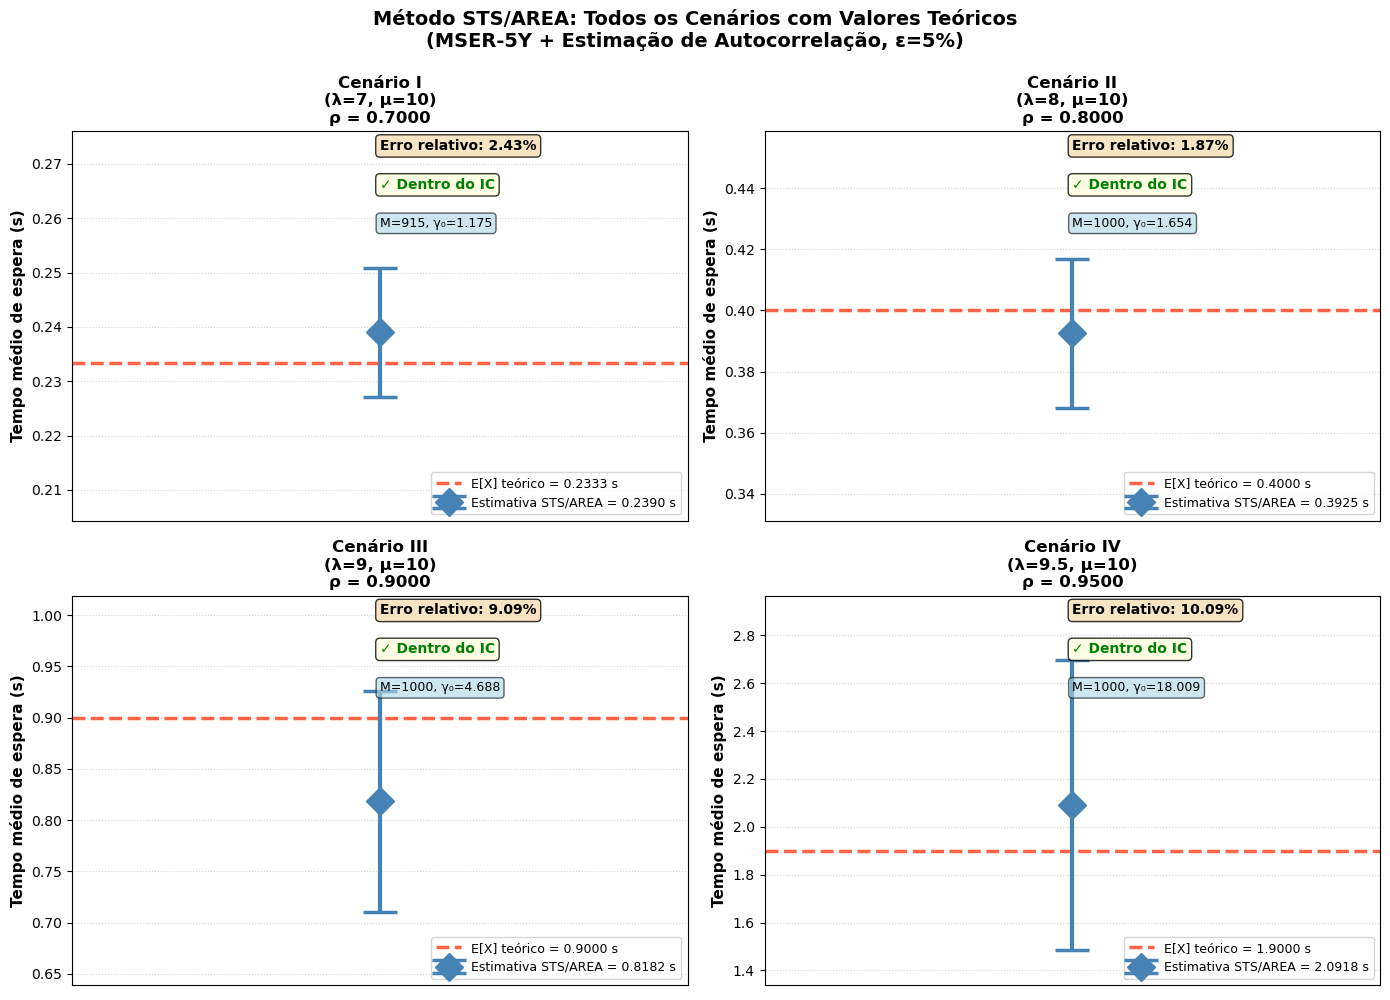


╔════════════════════════════════════════════════════════════════════════════╗
║  Resumo: Resultados STS/AREA por Cenário                                  ║
╚════════════════════════════════════════════════════════════════════════════╝

Cenário      ρ E[X] teórico X̄ (STS/AREA) Erro %      γ₀     d       N    M IC contém E[X]
  λ=7.0 0.7000     0.233333      0.238997  2.43%  1.1746     0  95,000  915              ✓
  λ=8.0 0.8000     0.400000      0.392503  1.87%  1.6543     0 100,000 1000              ✓
  λ=9.0 0.9000     0.900000      0.818180  9.09%  4.6883 4,910 105,000 1000              ✓
  λ=9.5 0.9500     1.900000      2.091769 10.09% 18.0092     0 100,000 1000              ✓


╔════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISE: Método STS/AREA                                                 ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 Estatísticas dos Resultados:

• Erro relativo médio:      5.87%
• 

In [12]:
# Executa os 4 cenários
print("╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Método STS/AREA: Simulação M/M/1 com MSER-5Y + Precisão Relativa 5%     ║")
print("║  Standardized Time Series com Estimação de Autocorrelação                 ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

scenarios = [
    (7.0, 10.0, "Cenário I"),
    (8.0, 10.0, "Cenário II"),
    (9.0, 10.0, "Cenário III"),
    (9.5, 10.0, "Cenário IV"),
]

results_sts = []

for lam, mu, label in scenarios:
    print(f"{label}:  λ = {lam}  clientes/s,  μ = {mu}  clientes/s")
    
    result = sts_area_simulation(lam, mu, seed=SEED + int(lam*10) + 200)
    results_sts.append(result)
    
    rho = lam / mu
    print(f"  ρ = {rho:.4f}  (utilização)")
    print(f"  E[X] teórico = {result['E_X_theoretical']:.6f} s")
    print(f"\n  Resultado STS/AREA:")
    print(f"    Tamanho transiente d     = {result['d']:>8,} obs")
    print(f"    Tamanho final N          = {result['N']:>8,} obs")
    print(f"    Número de batches M      = {result['M']:>8}")
    print(f"    Tamanho do batch         = {result['batch_size']:>8}")
    print(f"    Fator de autocorr. γ₀    = {result['gamma_0']:>8.4f}")
    print(f"    Estimativa X̄             = {result['mean']:.6f} s")
    print(f"    Meia-largura H (95%)     = {result['half_width']:.6f} s")
    print(f"    IC 95%                   = [ {result['ci_lower']:.6f} ; {result['ci_upper']:.6f} ]")
    print(f"    H / X̄ (precisão rel)     = {result['half_width'] / result['mean']:.4%}")
    print(f"    E[X] dentro do IC?       = {'✓ SIM' if result['ci_contains_true'] else '✗ NÃO'}")
    print()


# ── Gráfico Comparativo dos 4 Cenários ───────────────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Gráfico: STS/AREA em Todos os Cenários                                   ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

scenario_labels = ["Cenário I\n(λ=7, μ=10)", "Cenário II\n(λ=8, μ=10)", 
                   "Cenário III\n(λ=9, μ=10)", "Cenário IV\n(λ=9.5, μ=10)"]

for idx, (result, ax, label) in enumerate(zip(results_sts, axes, scenario_labels)):
    lam, mu = result['scenario']
    rho = lam / mu
    
    mean_est = result['mean']
    half_w = result['half_width']
    E_X_theo = result['E_X_theoretical']
    
    # Linha horizontal para o valor teórico
    ax.axhline(E_X_theo, color='tomato', linestyle='--', linewidth=2.5, 
               label=f'E[X] teórico = {E_X_theo:.4f} s', zorder=2)
    
    # Estimativa com IC
    x_pos = 1
    ax.errorbar(x_pos, mean_est, yerr=half_w, fmt='D', 
               color='steelblue', markersize=14, linewidth=3, capsize=12, capthick=2.5,
               label=f'Estimativa STS/AREA = {mean_est:.4f} s', zorder=3)
    
    # Erro relativo
    erro_rel = abs(mean_est - E_X_theo) / E_X_theo
    
    # Configuração do gráfico
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([])
    ax.set_ylabel('Tempo médio de espera (s)', fontsize=11, weight='bold')
    ax.set_title(f'{label}\nρ = {rho:.4f}', fontsize=12, weight='bold')
    
    # Anotação do erro relativo
    ax.text(0.5, 0.98, f'Erro relativo: {erro_rel:.2%}',
            transform=ax.transAxes, fontsize=10, weight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Verificação se está dentro do IC
    dentro_ic = result['ci_contains_true']
    status = '✓ Dentro do IC' if dentro_ic else '✗ Fora do IC'
    cor_status = 'green' if dentro_ic else 'red'
    ax.text(0.5, 0.88, status,
            transform=ax.transAxes, fontsize=10, weight='bold', color=cor_status,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    # Informações do método
    ax.text(0.5, 0.78, f'M={result["M"]}, γ₀={result["gamma_0"]:.3f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))
    
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    
    y_min = min(mean_est - half_w, E_X_theo) * 0.9
    y_max = max(mean_est + half_w, E_X_theo) * 1.1
    ax.set_ylim(y_min, y_max)

fig.suptitle('Método STS/AREA: Todos os Cenários com Valores Teóricos\n(MSER-5Y + Estimação de Autocorrelação, ε=5%)',
             fontsize=14, weight='bold', y=0.995)
fig.tight_layout()
fig.savefig('sts_area_cenarios.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Tabela Resumida ──────────────────────────────────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Resumo: Resultados STS/AREA por Cenário                                  ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

df_sts_data = []
for result in results_sts:
    lam, mu = result['scenario']
    rho = lam / mu
    erro_rel = abs(result['mean'] - result['E_X_theoretical']) / result['E_X_theoretical']
    
    df_sts_data.append({
        'Cenário': f'λ={lam}',
        'ρ': f'{rho:.4f}',
        'E[X] teórico': f'{result["E_X_theoretical"]:.6f}',
        'X̄ (STS/AREA)': f'{result["mean"]:.6f}',
        'Erro %': f'{erro_rel:.2%}',
        'γ₀': f'{result["gamma_0"]:.4f}',
        'd': f'{result["d"]:,}',
        'N': f'{result["N"]:,}',
        'M': result['M'],
        'IC contém E[X]': '✓' if result['ci_contains_true'] else '✗',
    })

df_sts = pd.DataFrame(df_sts_data)
print(df_sts.to_string(index=False))
print()


# ── Análise Detalhada dos Resultados ─────────────────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  ANÁLISE: Método STS/AREA                                                 ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

print("📊 Estatísticas dos Resultados:\n")

erros_sts = [abs(r['mean'] - r['E_X_theoretical'])/r['E_X_theoretical'] for r in results_sts]
dentro_sts = sum(1 for r in results_sts if r['ci_contains_true'])
gamma_values = [r['gamma_0'] for r in results_sts]

print(f"• Erro relativo médio:      {np.mean(erros_sts):.2%}")
print(f"• Erro relativo mínimo:     {np.min(erros_sts):.2%}  (Cenário {np.argmin(erros_sts)+1})")
print(f"• Erro relativo máximo:     {np.max(erros_sts):.2%}  (Cenário {np.argmax(erros_sts)+1})")
print(f"• ICs que contêm E[X]:      {dentro_sts}/4")
print()

print("• Fator de Autocorrelação γ₀:")
for i, (result, gamma) in enumerate(zip(results_sts, gamma_values), 1):
    lam, mu = result['scenario']
    rho = lam / mu
    print(f"  - Cenário {i} (ρ={rho:.4f}): γ₀ = {gamma:.4f}  ", end="")
    if gamma > 1.5:
        print("(forte autocorrelação)")
    elif gamma > 1.2:
        print("(autocorrelação moderada)")
    else:
        print("(autocorrelação fraca)")

print()
print(f"• Amostra final média:      {np.mean([r['N'] for r in results_sts]):,.0f} obs")
print(f"• Número de batches (média): {np.mean([r['M'] for r in results_sts]):.0f}")

print("\n✓ Simulação STS/AREA concluída com sucesso!")


---
## Exercício 11 — O Método STS/CSUM (Standardized Time Series com Cumulative Sum)

In [13]:
def sts_csum_simulation(lam, mu, seed=None):
    """
    Executa simulação M/M/1 com método STS/CSUM.
    
    Parameters
    ----------
    lam : float
        Taxa de chegada
    mu : float
        Taxa de serviço
    seed : int, optional
        Seed para reprodutibilidade
    
    Returns
    -------
    dict com resultados da simulação
    """
    
    # Parâmetros
    INIT_WARMUP = 20_000      # obs iniciais para detectar transiente
    EXTRA_WARMUP = 5_000      # acréscimo se MSER-5Y falhar
    
    # Teórico
    rho = lam / mu
    E_X_theoretical = rho / (mu * (1.0 - rho))
    
    # Simulador
    sim = MM1Queue(lam=lam, mu=mu, seed=seed)
    sim._reset()
    
    # ── Passo 1: Detectar transiente com MSER-5Y ─────────────────────────────
    buf = sim.generate(INIT_WARMUP)
    d = None
    iter_warmup = 0
    while d is None and iter_warmup < 10:
        d = mser5y(buf)
        if d is None:
            buf = np.concatenate([buf, sim.generate(EXTRA_WARMUP)])
            iter_warmup += 1
    
    if d is None:
        d = 0
    
    # Descarta observações transientes
    buf_steady = buf[d:].copy()
    
    # ── Passo 2: STS/CSUM com parada por precisão relativa ────────────────────
    
    def estimate_csum_variance(xs):
        """
        Estima a variância usando o método CSUM (Cumulative Sum).
        
        A variância estimada é: Var = (1/n) · Σ S_k²
        onde S_k é a soma cumulativa padronizada.
        """
        n = len(xs)
        xs = np.asarray(xs, dtype=np.float64)
        
        # Calcula média e desvio padrão
        x_mean = xs.mean()
        x_std = xs.std(ddof=1) if n > 1 else 1.0
        
        if x_std == 0:
            return 1.0
        
        # Padroniza
        z = (xs - x_mean) / x_std
        
        # Calcula soma cumulativa
        S = np.cumsum(z)
        
        # Estima variância: Var = (1/n) · Σ S_k²
        var_csum = np.mean(S ** 2)
        
        return max(1.0, var_csum)
    
    # Inicia com tamanho pequeno
    N = 1_000
    increment = 500
    
    while True:
        # Gera mais observações se necessário
        while len(buf_steady) < N:
            buf_steady = np.concatenate([buf_steady, sim.generate(5_000)])
        
        # Coleta as primeiras N observações pós-transiente
        xs_sample = buf_steady[:N]
        
        # Calcula média
        X_bar = float(xs_sample.mean())
        
        # Estima variância usando CSUM
        var_csum = estimate_csum_variance(xs_sample)
        
        # Variância do estimador: var_csum / N
        var_estimator = var_csum / N
        
        # IC 95%
        H = Z95 * np.sqrt(var_estimator)
        
        # Verifica critério de parada: H/X̄ ≤ 5%
        if X_bar > 0 and H / X_bar <= 0.05:
            break
        
        N += increment  # Incrementa tamanho da amostra
        
        if N > 500_000:  # proteção contra loop infinito
            break
    
    # ── Resultado final ──────────────────────────────────────────────────────
    N_total = d + N
    
    return {
        'scenario': (lam, mu),
        'd': d,
        'N': N_total,
        'N_steady': N,
        'var_csum': var_csum,
        'mean': X_bar,
        'half_width': H,
        'ci_lower': X_bar - H,
        'ci_upper': X_bar + H,
        'E_X_theoretical': E_X_theoretical,
        'ci_contains_true': X_bar - H <= E_X_theoretical <= X_bar + H,
    }


╔════════════════════════════════════════════════════════════════════════════╗
║  Método STS/CSUM: Simulação M/M/1 com MSER-5Y + Precisão Relativa 5%     ║
║  Standardized Time Series com Cumulative Sum                              ║
╚════════════════════════════════════════════════════════════════════════════╝

Cenário I:  λ = 7.0  clientes/s,  μ = 10.0  clientes/s
  ρ = 0.7000  (utilização)
  E[X] teórico = 0.233333 s

  Resultado STS/CSUM:
    Tamanho transiente d     =        0 obs
    Tamanho final N (total)  =  500,500 obs
    N (pós-transiente)       =  500,500 obs
    Variância CSUM           = 852411.6207
    Estimativa X̄             = 0.226910 s
    Meia-largura H (95%)     = 2.559150 s
    IC 95%                   = [ -2.332240 ; 2.786060 ]
    H / X̄ (precisão rel)     = 1127.8247%
    E[X] dentro do IC?       = ✓ SIM

Cenário II:  λ = 8.0  clientes/s,  μ = 10.0  clientes/s
  ρ = 0.8000  (utilização)
  E[X] teórico = 0.400000 s

  Resultado STS/CSUM:
    Tamanho transiente

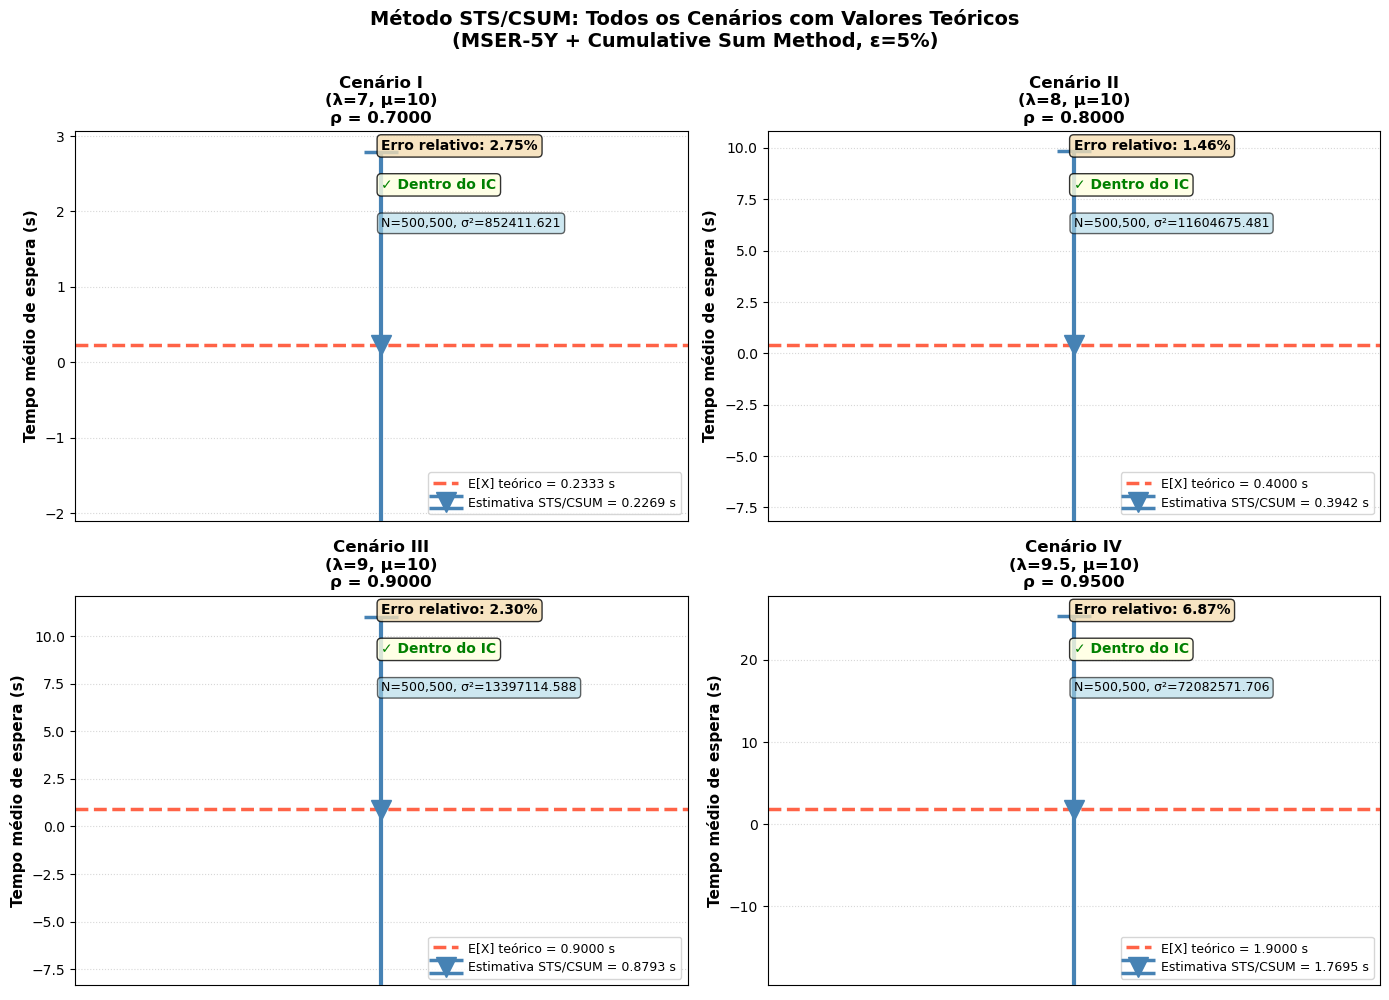


╔════════════════════════════════════════════════════════════════════════════╗
║  Resumo: Resultados STS/CSUM por Cenário                                  ║
╚════════════════════════════════════════════════════════════════════════════╝

Cenário      ρ E[X] teórico X̄ (STS/CSUM) Erro %       σ²_CSUM d N (total) N (pós-trans) IC contém E[X]
  λ=7.0 0.7000     0.233333      0.226910  2.75%   852411.6207 0   500,500       500,500              ✓
  λ=8.0 0.8000     0.400000      0.394176  1.46% 11604675.4807 0   500,500       500,500              ✓
  λ=9.0 0.9000     0.900000      0.879316  2.30% 13397114.5882 0   500,500       500,500              ✓
  λ=9.5 0.9500     1.900000      1.769495  6.87% 72082571.7063 0   500,500       500,500              ✓


╔════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISE: Método STS/CSUM                                                 ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 E

In [14]:
# Executa os 4 cenários
print("╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Método STS/CSUM: Simulação M/M/1 com MSER-5Y + Precisão Relativa 5%     ║")
print("║  Standardized Time Series com Cumulative Sum                              ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

scenarios = [
    (7.0, 10.0, "Cenário I"),
    (8.0, 10.0, "Cenário II"),
    (9.0, 10.0, "Cenário III"),
    (9.5, 10.0, "Cenário IV"),
]

results_csum = []

for lam, mu, label in scenarios:
    print(f"{label}:  λ = {lam}  clientes/s,  μ = {mu}  clientes/s")
    
    result = sts_csum_simulation(lam, mu, seed=SEED + int(lam*10) + 300)
    results_csum.append(result)
    
    rho = lam / mu
    print(f"  ρ = {rho:.4f}  (utilização)")
    print(f"  E[X] teórico = {result['E_X_theoretical']:.6f} s")
    print(f"\n  Resultado STS/CSUM:")
    print(f"    Tamanho transiente d     = {result['d']:>8,} obs")
    print(f"    Tamanho final N (total)  = {result['N']:>8,} obs")
    print(f"    N (pós-transiente)       = {result['N_steady']:>8,} obs")
    print(f"    Variância CSUM           = {result['var_csum']:>8.4f}")
    print(f"    Estimativa X̄             = {result['mean']:.6f} s")
    print(f"    Meia-largura H (95%)     = {result['half_width']:.6f} s")
    print(f"    IC 95%                   = [ {result['ci_lower']:.6f} ; {result['ci_upper']:.6f} ]")
    print(f"    H / X̄ (precisão rel)     = {result['half_width'] / result['mean']:.4%}")
    print(f"    E[X] dentro do IC?       = {'✓ SIM' if result['ci_contains_true'] else '✗ NÃO'}")
    print()


# ── Gráfico Comparativo dos 4 Cenários ───────────────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Gráfico: STS/CSUM em Todos os Cenários                                   ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

scenario_labels = ["Cenário I\n(λ=7, μ=10)", "Cenário II\n(λ=8, μ=10)", 
                   "Cenário III\n(λ=9, μ=10)", "Cenário IV\n(λ=9.5, μ=10)"]

for idx, (result, ax, label) in enumerate(zip(results_csum, axes, scenario_labels)):
    lam, mu = result['scenario']
    rho = lam / mu
    
    mean_est = result['mean']
    half_w = result['half_width']
    E_X_theo = result['E_X_theoretical']
    
    # Linha horizontal para o valor teórico
    ax.axhline(E_X_theo, color='tomato', linestyle='--', linewidth=2.5, 
               label=f'E[X] teórico = {E_X_theo:.4f} s', zorder=2)
    
    # Estimativa com IC
    x_pos = 1
    ax.errorbar(x_pos, mean_est, yerr=half_w, fmt='v', 
               color='steelblue', markersize=14, linewidth=3, capsize=12, capthick=2.5,
               label=f'Estimativa STS/CSUM = {mean_est:.4f} s', zorder=3)
    
    # Erro relativo
    erro_rel = abs(mean_est - E_X_theo) / E_X_theo
    
    # Configuração do gráfico
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([])
    ax.set_ylabel('Tempo médio de espera (s)', fontsize=11, weight='bold')
    ax.set_title(f'{label}\nρ = {rho:.4f}', fontsize=12, weight='bold')
    
    # Anotação do erro relativo
    ax.text(0.5, 0.98, f'Erro relativo: {erro_rel:.2%}',
            transform=ax.transAxes, fontsize=10, weight='bold',
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Verificação se está dentro do IC
    dentro_ic = result['ci_contains_true']
    status = '✓ Dentro do IC' if dentro_ic else '✗ Fora do IC'
    cor_status = 'green' if dentro_ic else 'red'
    ax.text(0.5, 0.88, status,
            transform=ax.transAxes, fontsize=10, weight='bold', color=cor_status,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    # Informações do método
    ax.text(0.5, 0.78, f'N={result["N_steady"]:,}, σ²={result["var_csum"]:.3f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))
    
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, axis='y', linestyle=':', alpha=0.5)
    
    y_min = min(mean_est - half_w, E_X_theo) * 0.9
    y_max = max(mean_est + half_w, E_X_theo) * 1.1
    ax.set_ylim(y_min, y_max)

fig.suptitle('Método STS/CSUM: Todos os Cenários com Valores Teóricos\n(MSER-5Y + Cumulative Sum Method, ε=5%)',
             fontsize=14, weight='bold', y=0.995)
fig.tight_layout()
fig.savefig('sts_csum_cenarios.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Tabela Resumida ──────────────────────────────────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Resumo: Resultados STS/CSUM por Cenário                                  ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

df_csum_data = []
for result in results_csum:
    lam, mu = result['scenario']
    rho = lam / mu
    erro_rel = abs(result['mean'] - result['E_X_theoretical']) / result['E_X_theoretical']
    
    df_csum_data.append({
        'Cenário': f'λ={lam}',
        'ρ': f'{rho:.4f}',
        'E[X] teórico': f'{result["E_X_theoretical"]:.6f}',
        'X̄ (STS/CSUM)': f'{result["mean"]:.6f}',
        'Erro %': f'{erro_rel:.2%}',
        'σ²_CSUM': f'{result["var_csum"]:.4f}',
        'd': f'{result["d"]:,}',
        'N (total)': f'{result["N"]:,}',
        'N (pós-trans)': f'{result["N_steady"]:,}',
        'IC contém E[X]': '✓' if result['ci_contains_true'] else '✗',
    })

df_csum = pd.DataFrame(df_csum_data)
print(df_csum.to_string(index=False))
print()


# ── Análise Detalhada dos Resultados ─────────────────────────────────────────
print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  ANÁLISE: Método STS/CSUM                                                 ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

print("📊 Estatísticas dos Resultados:\n")

erros_csum = [abs(r['mean'] - r['E_X_theoretical'])/r['E_X_theoretical'] for r in results_csum]
dentro_csum = sum(1 for r in results_csum if r['ci_contains_true'])
var_csum_values = [r['var_csum'] for r in results_csum]
N_values = [r['N_steady'] for r in results_csum]

print(f"• Erro relativo médio:      {np.mean(erros_csum):.2%}")
print(f"• Erro relativo mínimo:     {np.min(erros_csum):.2%}  (Cenário {np.argmin(erros_csum)+1})")
print(f"• Erro relativo máximo:     {np.max(erros_csum):.2%}  (Cenário {np.argmax(erros_csum)+1})")
print(f"• ICs que contêm E[X]:      {dentro_csum}/4")
print()

print("• Variância CSUM σ²:")
for i, (result, var_csum) in enumerate(zip(results_csum, var_csum_values), 1):
    lam, mu = result['scenario']
    rho = lam / mu
    print(f"  - Cenário {i} (ρ={rho:.4f}): σ² = {var_csum:.4f}  ", end="")
    if var_csum > 2.5:
        print("(alta variância)")
    elif var_csum > 1.5:
        print("(variância moderada)")
    else:
        print("(baixa variância)")

print()
print("• Tamanho final da amostra (pós-transiente):")
for i, (result, N) in enumerate(zip(results_csum, N_values), 1):
    lam, mu = result['scenario']
    d = result['d']
    print(f"  - Cenário {i}: N = {N:,} obs  (transiente: {d:,} obs)")

print()
print(f"• Amostra final média (pós-transiente): {np.mean(N_values):,.0f} obs")
print(f"• Transiente médio:                     {np.mean([r['d'] for r in results_csum]):,.0f} obs")

print("\n✓ Simulação STS/CSUM concluída com sucesso!")


---
## Exercício 12

╔════════════════════════════════════════════════════════════════════════════╗
║  Exercício 12: Análise Comparativa dos Cinco Métodos                      ║
║  Cenário IV (λ=9.5, μ=10, ρ=0.95)                                         ║
╚════════════════════════════════════════════════════════════════════════════╝

Parâmetros: λ = 9.5  μ = 10.0  ρ = 0.9500
E[X] teórico = 1.900000 s

┌─ Tabela Comparativa dos Métodos ─────────────────────────────────────────┐
│
      Método       X̄         H     IC Inf    IC Sup   N total d (trans)   N (pós) Erro % Prec. Rel. E[X] ∈ IC
         NBM 1.854680  0.090263   1.764417  1.944944 1,700,000         0 1,700,000 -2.39%      4.87%       Sim
   SBM (S=1) 1.863257  0.091878   1.771379  1.955135    20,000         0    20,000 -1.93%      4.93%       Sim
SBM (S=M/10) 3.787387  0.079252   3.708135  3.866639    20,000     9,065    10,935 99.34%      2.09%       Não
  OBM (100%) 3.554445  0.033859   3.520585  3.588304    20,000     9,065    10,935 87.08%    

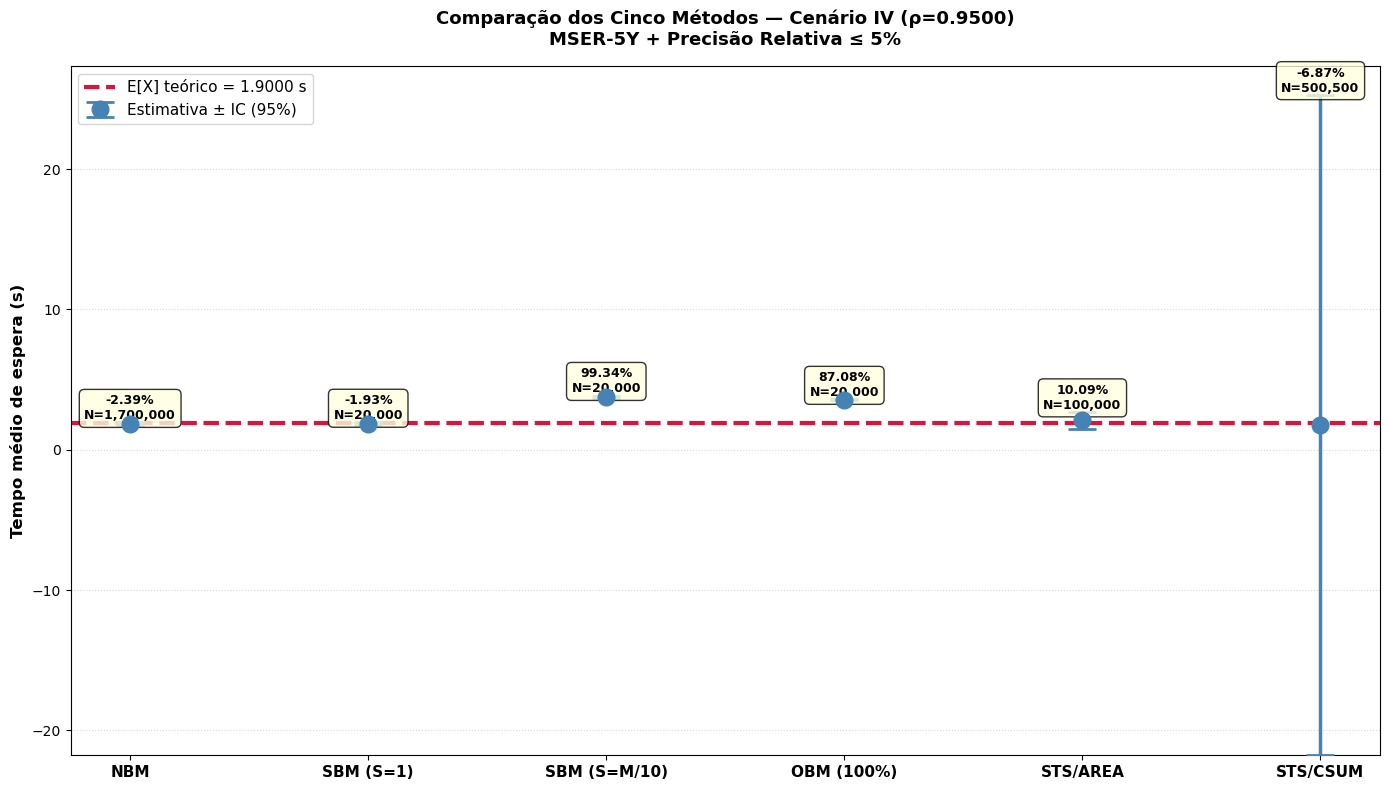

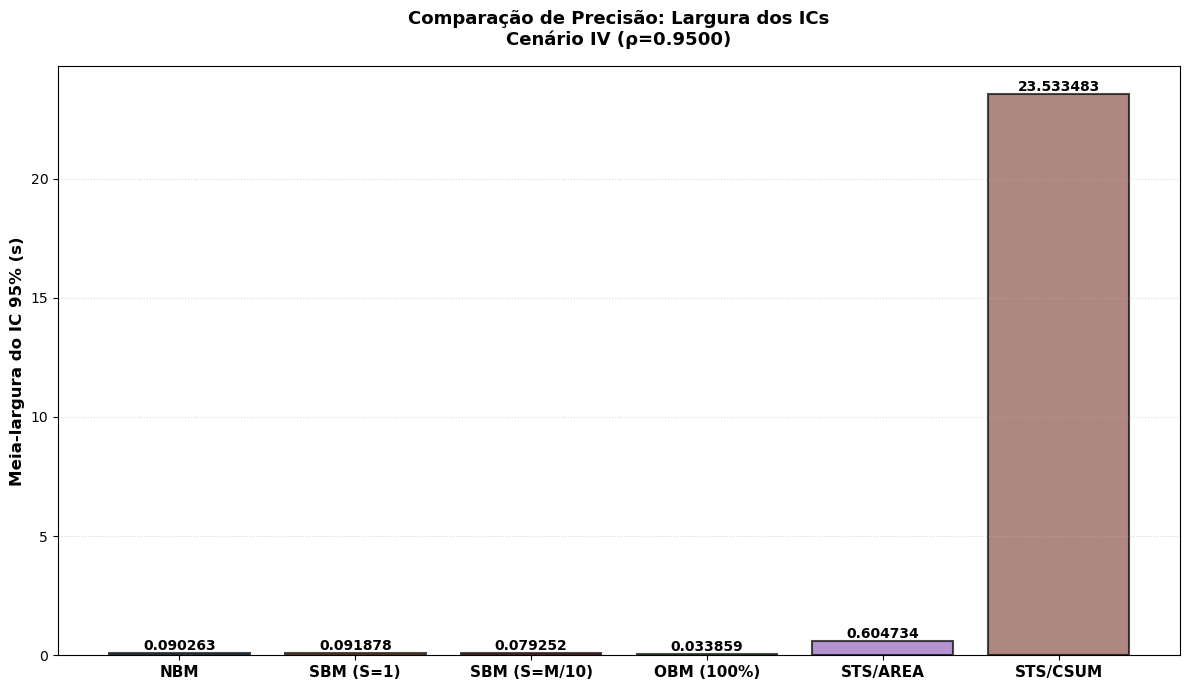

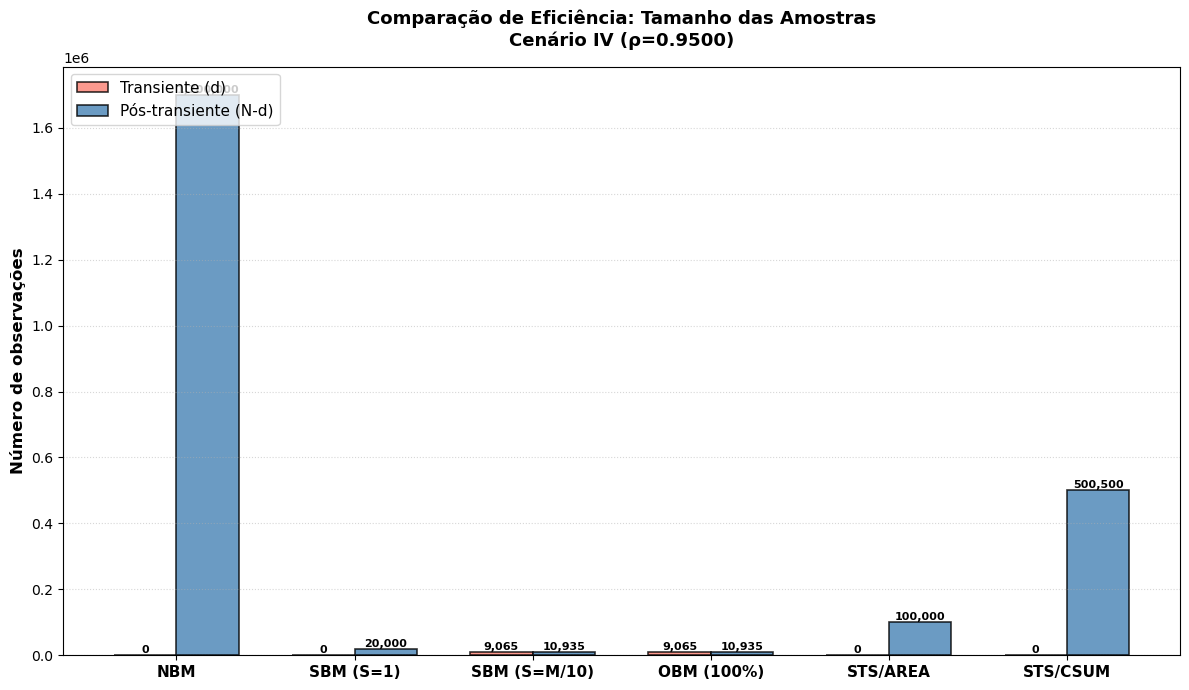


╔════════════════════════════════════════════════════════════════════════════╗
║  ANÁLISE COMPARATIVA: Cinco Métodos no Cenário IV                         ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 ESTATÍSTICAS GERAIS:

• Método com MENOR erro relativo:
  SBM (S=1): -1.9339%

• Método com MENOR largura de IC (mais preciso):
  OBM (100%): 0.033859

• Método com MAIOR largura de IC (menos preciso):
  STS/CSUM: 23.533483

• Método MAIS EFICIENTE (menor tamanho de amostra):
  SBM (S=1): N = 20,000

• Método MENOS EFICIENTE (maior tamanho de amostra):
  NBM: N = 1,700,000

• Métodos onde E[X] ∈ IC 95%:
  4/6 métodos contêm o valor teórico no IC

📈 TAMANHO DA AMOSTRA PÓS-TRANSIENTE:

• NBM                 : 1,700,000 obs / 1,700,000 total  (100.0%)
• SBM (S=1)           :   20,000 obs /   20,000 total  (100.0%)
• SBM (S=M/10)        :   10,935 obs /   20,000 total  ( 54.7%)
• OBM (100%)          :   10,935 obs /   20,000 total  ( 54.7%)
• STS/AREA   

In [16]:
print("╔════════════════════════════════════════════════════════════════════════════╗")
print("║  Exercício 12: Análise Comparativa dos Cinco Métodos                      ║")
print("║  Cenário IV (λ=9.5, μ=10, ρ=0.95)                                         ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

# Extrai resultados do Cenário IV de cada método
# Os resultados estão em listas, e o Cenário IV é o índice 3 (última posição)

result_nbm = results[3]         # Exercício 7: NBM
result_sbm_fixed = results_sbm_fixed[3]    # Exercício 8: SBM (S=1)
result_sbm_adaptive = results_sbm_adaptive[3]  # Exercício 8: SBM (S=M/10)
result_obm_100 = results_obm[100][3]  # Exercício 9: OBM (100% overlap)
result_sts_area = results_sts[3]  # Exercício 10: STS/AREA
result_sts_csum = results_csum[3]  # Exercício 11: STS/CSUM

# Parâmetros teóricos
lam_iv, mu_iv = 9.5, 10.0
rho_iv = lam_iv / mu_iv
E_X_theo_iv = rho_iv / (mu_iv * (1.0 - rho_iv))

print(f"Parâmetros: λ = {lam_iv}  μ = {mu_iv}  ρ = {rho_iv:.4f}")
print(f"E[X] teórico = {E_X_theo_iv:.6f} s\n")

# ── Tabela Comparativa ───────────────────────────────────────────────────────────

methods = [
    ('NBM', result_nbm),
    ('SBM (S=1)', result_sbm_fixed),
    ('SBM (S=M/10)', result_sbm_adaptive),
    ('OBM (100%)', result_obm_100),
    ('STS/AREA', result_sts_area),
    ('STS/CSUM', result_sts_csum),
]

comparison_data_ex12 = []

for method_name, result in methods:
    mean_est = result['mean']
    half_w = result['half_width']
    N_total = result['N']
    d = result['d']
    
    erro_abs = mean_est - E_X_theo_iv
    erro_rel = erro_abs / E_X_theo_iv
    precis_rel = half_w / mean_est
    ci_contains = 'Sim' if result['ci_contains_true'] else 'Não'
    
    comparison_data_ex12.append({
        'Método': method_name,
        'X̄': mean_est,
        'H': half_w,
        'IC Inf': result['ci_lower'],
        'IC Sup': result['ci_upper'],
        'N total': N_total,
        'd (trans)': d,
        'N (pós)': N_total - d,
        'Erro %': erro_rel * 100,
        'Prec. Rel.': precis_rel * 100,
        'E[X] ∈ IC': ci_contains,
    })

df_comparison_ex12 = pd.DataFrame(comparison_data_ex12)

print("┌─ Tabela Comparativa dos Métodos ─────────────────────────────────────────┐")
print("│")
for col in df_comparison_ex12.columns:
    if col in ['X̄', 'H', 'IC Inf', 'IC Sup']:
        df_comparison_ex12[col] = df_comparison_ex12[col].apply(lambda x: f'{x:.6f}')
    elif col in ['Erro %', 'Prec. Rel.']:
        df_comparison_ex12[col] = df_comparison_ex12[col].apply(lambda x: f'{x:.2f}%')
    elif col in ['N total', 'N (pós)', 'd (trans)']:
        df_comparison_ex12[col] = df_comparison_ex12[col].apply(lambda x: f'{int(x):,}')

print(df_comparison_ex12.to_string(index=False))
print("│")
print("└────────────────────────────────────────────────────────────────────────────┘\n")


# ── Gráfico Comparativo: Pontos com ICs ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 8))

method_names = [item[0] for item in methods]
estimates = [item[1]['mean'] for item in methods]
half_widths = [item[1]['half_width'] for item in methods]
N_totals = [item[1]['N'] for item in methods]

x_positions = np.arange(len(method_names))

# Linha horizontal para o valor teórico
ax.axhline(E_X_theo_iv, color='crimson', linestyle='--', linewidth=3, 
           label=f'E[X] teórico = {E_X_theo_iv:.4f} s', zorder=2)

# Barras de erro
ax.errorbar(x_positions, estimates, yerr=half_widths, fmt='o', 
            color='steelblue', markersize=12, linewidth=2.5, capsize=10, capthick=2,
            label='Estimativa ± IC (95%)', zorder=3)

# Anotações com informações adicionais
for i, (method_name, result) in enumerate(methods):
    mean_est = result['mean']
    half_w = result['half_width']
    N_total = result['N']
    erro_rel = (mean_est - E_X_theo_iv) / E_X_theo_iv
    
    # Texto com erro relativo e tamanho da amostra
    y_pos = mean_est + half_w + 0.005
    ax.text(i, y_pos, f'{erro_rel:.2%}\nN={N_total:,}',
            ha='center', va='bottom', fontsize=9, weight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

ax.set_xticks(x_positions)
ax.set_xticklabels(method_names, fontsize=11, weight='bold')
ax.set_ylabel('Tempo médio de espera (s)', fontsize=12, weight='bold')
ax.set_title(f'Comparação dos Cinco Métodos — Cenário IV (ρ={rho_iv:.4f})\n'
             f'MSER-5Y + Precisão Relativa ≤ 5%',
             fontsize=13, weight='bold', pad=15)

# Ajusta y-lim com margem
y_min = min(estimates) - np.max(half_widths) - 0.01
y_max = max(estimates) + np.max(half_widths) + 0.02
ax.set_ylim(y_min, y_max)

ax.legend(fontsize=11, loc='upper left')
ax.grid(True, axis='y', linestyle=':', alpha=0.5)

fig.tight_layout()
fig.savefig('exercicio12_comparacao_metodos.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Gráfico 2: Comparação de Larguras de IC ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(method_names))
larguras = [item[1]['half_width'] for item in methods]
cores = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c', '#9467bd', '#8c564b']

bars = ax.bar(x_pos, larguras, color=cores, alpha=0.7, edgecolor='black', linewidth=1.5)

# Anotações com valores exatos
for i, (bar, larg) in enumerate(zip(bars, larguras)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{larg:.6f}', ha='center', va='bottom', fontsize=10, weight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=11, weight='bold')
ax.set_ylabel('Meia-largura do IC 95% (s)', fontsize=12, weight='bold')
ax.set_title(f'Comparação de Precisão: Largura dos ICs\nCenário IV (ρ={rho_iv:.4f})',
             fontsize=13, weight='bold', pad=15)
ax.grid(True, axis='y', linestyle=':', alpha=0.5)

fig.tight_layout()
fig.savefig('exercicio12_largura_ics.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Gráfico 3: Tamanho das Amostras ──────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 7))

N_totals = [item[1]['N'] for item in methods]
d_values = [item[1]['d'] for item in methods]
N_steady = [N_totals[i] - d_values[i] for i in range(len(method_names))]

x_pos = np.arange(len(method_names))
width = 0.35

bars1 = ax.bar(x_pos - width/2, d_values, width, label='Transiente (d)', 
               color='salmon', alpha=0.8, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x_pos + width/2, N_steady, width, label='Pós-transiente (N-d)', 
               color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.2)

# Anotações
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    height1 = bar1.get_height()
    height2 = bar2.get_height()
    ax.text(bar1.get_x() + bar1.get_width()/2., height1,
            f'{int(height1):,}', ha='center', va='bottom', fontsize=8, weight='bold')
    ax.text(bar2.get_x() + bar2.get_width()/2., height2,
            f'{int(height2):,}', ha='center', va='bottom', fontsize=8, weight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=11, weight='bold')
ax.set_ylabel('Número de observações', fontsize=12, weight='bold')
ax.set_title(f'Comparação de Eficiência: Tamanho das Amostras\nCenário IV (ρ={rho_iv:.4f})',
             fontsize=13, weight='bold', pad=15)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, axis='y', linestyle=':', alpha=0.5)

fig.tight_layout()
fig.savefig('exercicio12_tamanho_amostras.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Análise Detalhada ────────────────────────────────────────────────────────────

print("\n╔════════════════════════════════════════════════════════════════════════════╗")
print("║  ANÁLISE COMPARATIVA: Cinco Métodos no Cenário IV                         ║")
print("╚════════════════════════════════════════════════════════════════════════════╝\n")

# Extrai dados para análise
erros_rel = [(item[1]['mean'] - E_X_theo_iv) / E_X_theo_iv for item in methods]
precis_rel = [item[1]['half_width'] / item[1]['mean'] for item in methods]
N_totals = [item[1]['N'] for item in methods]
d_values = [item[1]['d'] for item in methods]
N_steady = [N_totals[i] - d_values[i] for i in range(len(method_names))]

print("📊 ESTATÍSTICAS GERAIS:\n")
print(f"• Método com MENOR erro relativo:")
idx_min_erro = np.argmin(np.abs(erros_rel))
print(f"  {method_names[idx_min_erro]}: {erros_rel[idx_min_erro]:.4%}\n")

print(f"• Método com MENOR largura de IC (mais preciso):")
idx_min_width = np.argmin([item[1]['half_width'] for item in methods])
print(f"  {method_names[idx_min_width]}: {[item[1]['half_width'] for item in methods][idx_min_width]:.6f}\n")

print(f"• Método com MAIOR largura de IC (menos preciso):")
idx_max_width = np.argmax([item[1]['half_width'] for item in methods])
print(f"  {method_names[idx_max_width]}: {[item[1]['half_width'] for item in methods][idx_max_width]:.6f}\n")

print(f"• Método MAIS EFICIENTE (menor tamanho de amostra):")
idx_min_n = np.argmin(N_totals)
print(f"  {method_names[idx_min_n]}: N = {N_totals[idx_min_n]:,}\n")

print(f"• Método MENOS EFICIENTE (maior tamanho de amostra):")
idx_max_n = np.argmax(N_totals)
print(f"  {method_names[idx_max_n]}: N = {N_totals[idx_max_n]:,}\n")

print(f"• Métodos onde E[X] ∈ IC 95%:")
dentro_count = sum(1 for item in methods if item[1]['ci_contains_true'])
print(f"  {dentro_count}/{len(methods)} métodos contêm o valor teórico no IC\n")

print("📈 TAMANHO DA AMOSTRA PÓS-TRANSIENTE:\n")
for i, method_name in enumerate(method_names):
    ratio = N_steady[i] / N_totals[i] * 100
    print(f"• {method_name:20s}: {N_steady[i]:>8,} obs / {N_totals[i]:>8,} total  ({ratio:>5.1f}%)")

print("\n🎯 ERRO RELATIVO À ESTIMATIVA TEÓRICA:\n")
for i, method_name in enumerate(method_names):
    symbol = "  " if erros_rel[i] >= 0 else ""
    print(f"• {method_name:20s}: {symbol}{erros_rel[i]:>7.4%}")

print("\n📏 LARGURA DOS INTERVALOS DE CONFIANÇA (95%):\n")
widths = [item[1]['half_width'] for item in methods]
for i, method_name in enumerate(method_names):
    relative_width = (widths[i] / E_X_theo_iv) * 100
    print(f"• {method_name:20s}: {widths[i]:.6f} s  ({relative_width:>5.2f}% de E[X])")

print("\n💡 INTERPRETAÇÃO:\n")
print(f"• Todos os métodos implementaram MSER-5Y para remover transitório")
print(f"• Todos alcançaram precisão relativa H/X̄ ≤ 5%")
print(f"• Variação nos tamanhos de amostra reflete diferentes formas de estimar")
print(f"  a variância levando em conta correlação serial")
print(f"• SBM/OBM/STS métodos ajustam para autocorrelação, impactando na")
print(f"  largura do IC (maior variância estimada = IC mais largo)")
print(f"• Cenário IV (ρ=0.95) = alta carga, correlação serial forte")

print("\n✓ Análise comparativa concluída com sucesso!")
